In [1]:
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import seaborn as sns
import os
import glob
from datetime import datetime
from datetime import timedelta
from matplotlib import pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
from matplotlib import cm
import matplotlib.dates as mdates
from scipy.interpolate import interp2d
warnings.filterwarnings('ignore')
#import datetime
import scipy.ndimage as ndimage
from matplotlib import cm
import geopy.distance
#import matplotlib as mpl
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import leafmap
import plotly.express as px
import matplotlib as mpl
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
import math
#import pysplit
import netCDF4
import xarray as xr
import re

Cannot find header.dxf (GDAL_DATA is not defined)


In [2]:
csv_file_path = 'C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/Leg_Index_2020/Taiwo_Impnew.xlsx' 
# Read the CSV file into a pandas DataFrame
IMPROVE = pd.read_excel(csv_file_path)
IMPROVE['Date'] = pd.to_datetime(IMPROVE['Date'])

IMPROVE.replace(-999, np.nan, inplace=True)

In [3]:
IMPROVE

,Dataset,SiteCode,POC,Date,AuxID,SiteName,Latitude,Longitude,State,EPACode,...,Sf_MDL,TIf_Val,TIf_MDL,Vf_Val,Vf_MDL,ZNf_Val,ZNf_MDL,ZRf_Val,ZRf_MDL,region
0,IMPAER,ATLA1,1,2018-01-02,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE
1,IMPAER,ATLA1,1,2018-01-05,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE
2,IMPAER,ATLA1,1,2018-01-08,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE
3,IMPAER,ATLA1,1,2018-01-11,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE
4,IMPAER,ATLA1,1,2018-01-14,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22945,IMPAER,SWAN1,2,2022-12-19,0,Swanquarter,35.451,-76.2075,NC,370959000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E
22946,IMPAER,SWAN1,2,2022-12-22,0,Swanquarter,35.451,-76.2075,NC,370959000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E
22947,IMPAER,SWAN1,2,2022-12-25,0,Swanquarter,35.451,-76.2075,NC,370959000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E
22948,IMPAER,SWAN1,2,2022-12-28,0,Swanquarter,35.451,-76.2075,NC,370959000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E


In [4]:
IMPROVE.loc[IMPROVE["OCf_Val"] > 4, "OCf_Val"] = np.nan
IMPROVE.loc[IMPROVE["ECf_Val"] > 0.8, "ECf_Val"] = np.nan
IMPROVE.loc[IMPROVE["SOILf_Val"] > 2, "SOILf_Val"] = np.nan
IMPROVE.loc[IMPROVE["SO4f_Val"] > 3, "SO4f_Val"] = np.nan
IMPROVE.loc[IMPROVE["NO3f_Val"] > 2.5, "NO3f_Val"] = np.nan
IMPROVE.loc[IMPROVE["RCFM_Val"] > 12, "RCFM_Val"] = np.nan
IMPROVE.loc[IMPROVE["CM_calculated_Val"] > 15, "CM_calculated_Val"] = np.nan


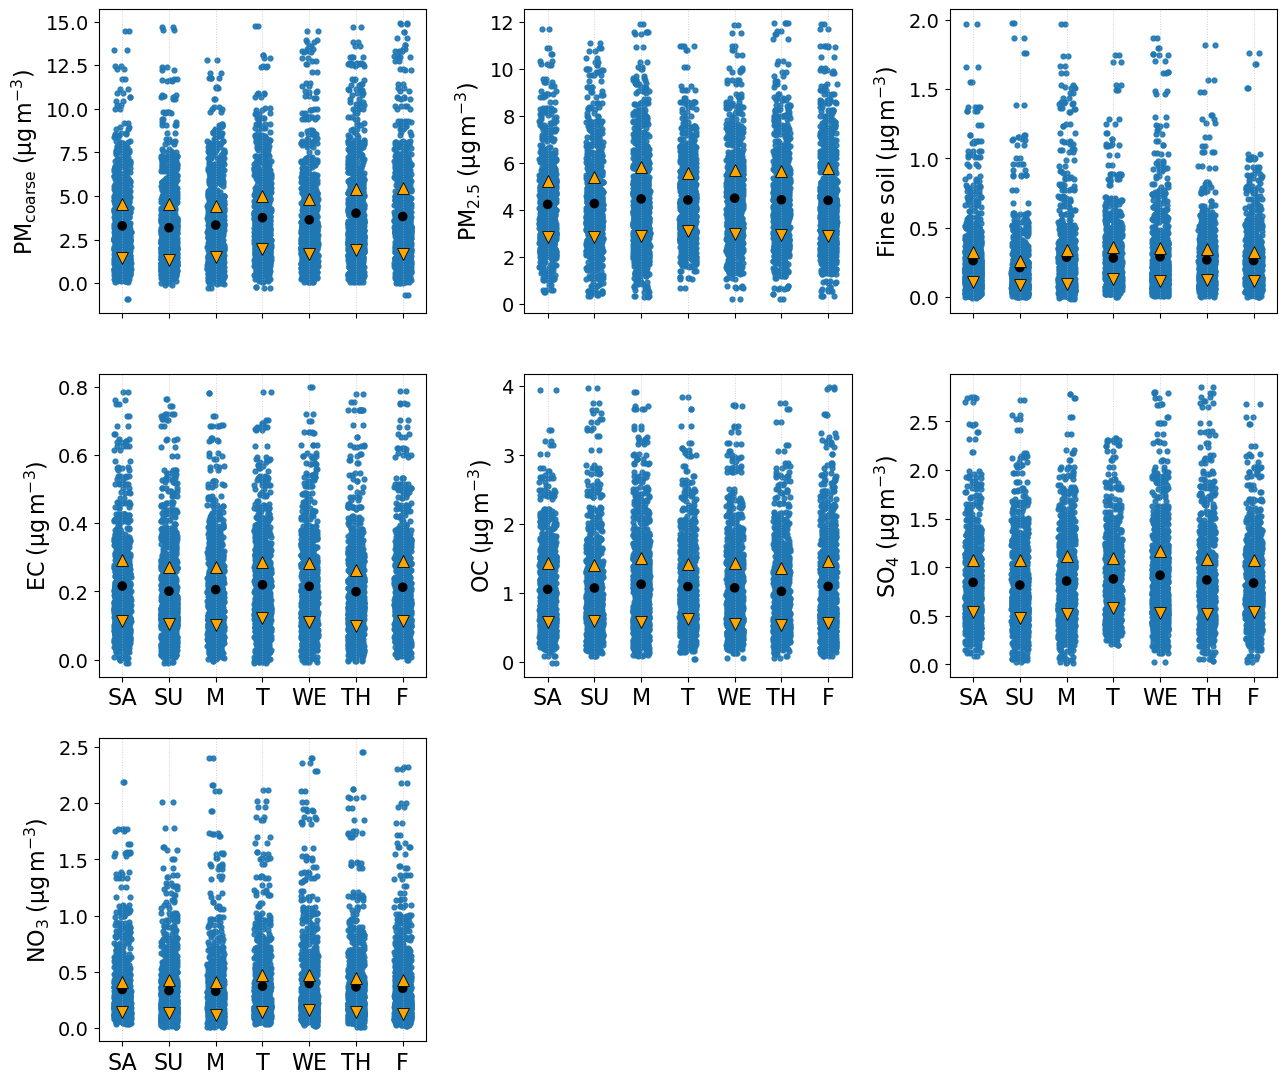

In [5]:
# file: plots/weekday_points_grid.py
from __future__ import annotations

from math import ceil, sqrt
from typing import Optional, Sequence, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["mathtext.default"] = "rm"

# --- Inputs you provided ------------------------------------------------------
target_sites = [
    "Brigantine NWR",
    "Dolly Sods Wilderness",
    "James River Face Wilderness",
    "Shenandoah NP",
    "Swanquarter",
    "Cape Romain NWR",
]

variables = {
    "CM_calculated_Val": r"$\mathrm{PM_{coarse}}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "RCFM_Val":          r"$\mathrm{PM_{2.5}}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "SOILf_Val":         r"$\mathrm{Fine\ soil}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "ECf_Val":           r"$\mathrm{EC}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "OCf_Val":           r"$\mathrm{OC}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "SO4f_Val":          r"$\mathrm{SO_{4}}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "NO3f_Val":          r"$\mathrm{NO_{3}}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
}
# -----------------------------------------------------------------------------

DEFAULT_DAYS_ORDER: tuple[str, ...] = (
    "Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"
)
SHORT_DAY = {
    "Saturday": "SA", "Sunday": "SU", "Monday": "M",
    "Tuesday": "T", "Wednesday": "WE", "Thursday": "TH", "Friday": "F"
}

# Column labels for y-axes (use your variables dict)
COLUMN_LABELS = variables.copy()

SITE_COL_CANDIDATES = ["Local Site Name", "SiteName", "site", "Site"]
DATE_COL_CANDIDATES = ["Date Local", "Date", "Sample Date", "Datetime", "datetime", "Time_Start"]


def _detect_col(df: pd.DataFrame, candidates: List[str]) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"None of {candidates} found in DataFrame.")


def _weekday_series(df: pd.DataFrame, time_col: str) -> pd.Series:
    if time_col not in df.columns:
        raise ValueError(f"Column '{time_col}' not found in DataFrame.")
    return pd.to_datetime(df[time_col], errors="coerce").dt.day_name()


def _safe_set_text(setter, text: str):
    try:
        setter(text)
    except Exception:
        setter(text.replace("$", "").replace(r"\mathrm", "").replace(r"\mu", "µ"))  # minimal fallback


def plot_weekday_points_grid(
    df: pd.DataFrame,
    columns: Sequence[str],
    *,
    time_col: str,
    days_order: Optional[Sequence[str]] = None,
    jitter: float = 0.18,
    seed: Optional[int] = 42,
    max_cols: Optional[int] = None,
    figsize_per: tuple[float, float] = (4.2, 4),
    point_size: float = 12.0,
    alpha: float = 0.9,
    show_titles: bool = False,
    ylabels: str = "all",            # 'all' | 'left' | 'none'
    xlabel_rotation: int = 0,
    xlabel_size: int = 16,
    ytick_size: Optional[int] = None,
    ylabel_size: Optional[int] = None,
    # spacing controls
    wspace: float = 0.08,
    hspace: float = 0.05,
    left: float = 0.06,
    right: float = 0.99,
    top: float = 0.92,
    bottom: float = 0.06,
    title: str = "",
    use_iqr: bool = True,            # mean + IQR markers
) -> None:
    days_order = tuple(days_order) if days_order is not None else DEFAULT_DAYS_ORDER

    missing = [c for c in columns if c not in df.columns]
    present = [c for c in columns if c in df.columns]
    if not present:
        raise ValueError("None of the requested columns exist in the DataFrame.")
    if missing:
        print(f"Warning: skipping missing columns: {missing}")

    weekdays = _weekday_series(df, time_col)
    pos_map = {d: i for i, d in enumerate(days_order)}

    n = len(present)
    ncols = max(1, int(ceil(sqrt(n)))) if max_cols is None else max(1, int(max_cols))
    nrows = int(ceil(n / ncols))

    fig_w = max(6.0, ncols * figsize_per[0])
    fig_h = max(4.0, nrows * figsize_per[1])
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(fig_w, fig_h),
        gridspec_kw={"wspace": wspace, "hspace": hspace}
    )
    axes_arr = np.atleast_1d(axes).ravel()

    tick_locs = list(range(len(days_order)))
    short_labels = [SHORT_DAY.get(d, d) for d in days_order]

    rows_to_label = {nrows - 1}
    if nrows >= 2 and (n % ncols != 0):
        rows_to_label.add(nrows - 2)

    if ytick_size is None:
        ytick_size = xlabel_size
    if ylabel_size is None:
        ylabel_size = xlabel_size

    for idx, col in enumerate(present):
        ax = axes_arr[idx]
        mask = weekdays.notna() & df[col].notna() & weekdays.isin(days_order)

        label_text = COLUMN_LABELS.get(col, col)

        if not mask.any():
            target = ax.set_title if show_titles else ax.set_ylabel
            _safe_set_text(target, label_text)
            ax.yaxis.label.set_fontsize(ylabel_size)
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.tick_params(axis="y", labelsize=ytick_size)
            continue

        x_base = weekdays[mask].map(pos_map).to_numpy()
        rng = np.random.default_rng(None if seed is None else (int(seed) + idx))
        x = x_base + rng.uniform(-jitter, jitter, size=x_base.size)
        y = df.loc[mask, col].astype(float).to_numpy()

        # raw points
        ax.scatter(x, y, s=point_size, alpha=alpha)

        # mean + IQR markers at same x
        stats_df = pd.DataFrame({"pos": x_base, "y": y})
        grp = stats_df.groupby("pos", sort=True)["y"]

        x_pos = grp.mean().index.to_numpy()
        means = grp.mean().to_numpy()

        # Mean marker (red circle)
        ax.scatter(x_pos, means, s=point_size * 4, marker="o",
                   color="k", edgecolors="none", alpha=1.0, zorder=15)

        if use_iqr:
            q1 = grp.quantile(0.25).to_numpy()
            q3 = grp.quantile(0.75).to_numpy()
            ok = np.isfinite(q1) & np.isfinite(q3)
            # IQR endpoints: green triangles exactly at Q1 (down) and Q3 (up)
            ax.scatter(x_pos[ok], q1[ok], s=point_size * 6, marker="v",
                       color="orange", edgecolors="k", linewidths=0.6, alpha=1.0, zorder=15)
            ax.scatter(x_pos[ok], q3[ok], s=point_size * 6, marker="^",
                       color="orange", edgecolors="k", linewidths=0.6, alpha=1.0, zorder=15)
        

        ax.set_xlim(-0.5, len(days_order) - 0.5)
        ax.set_xticks(tick_locs)
        row = idx // ncols
        if row in rows_to_label:
            ax.set_xticklabels(short_labels, rotation=xlabel_rotation, fontsize=xlabel_size)
        else:
            ax.set_xticklabels([])

        ax.grid(True, axis="x", linestyle=":", linewidth=0.7, alpha=0.6)

        if ylabels == "all" or (ylabels == "left" and idx % ncols == 0):
            _safe_set_text(ax.set_ylabel, label_text)
            ax.yaxis.label.set_fontsize(ylabel_size)
        ax.tick_params(axis="y", labelsize=ytick_size)

        if show_titles:
            _safe_set_text(ax.set_title, label_text)

    # hide unused slots
    for j in range(n, len(axes_arr)):
        axes_arr[j].axis("off")

    if title:
        fig.suptitle(title, y=top + 0.02)
    fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom)
    plt.show()


# ---------------- Runner for your IMPROVE DF ----------------
def plot_improve_weekday_raw_mean_iqr(
    IMPROVE: pd.DataFrame,
    *,
    target_sites: list[str],
    variables: dict[str, str],
    max_cols: int = 3,
) -> None:
    """Filter to target sites, keep requested variables, and plot raw + mean/IQR."""
    site_col = _detect_col(IMPROVE, SITE_COL_CANDIDATES)
    date_col = _detect_col(IMPROVE, DATE_COL_CANDIDATES)

    df_sel = IMPROVE.loc[IMPROVE[site_col].isin(target_sites)].copy()
    if df_sel.empty:
        raise ValueError("No rows matched target_sites. Check names and site column.")

    cols_present = [c for c in variables.keys() if c in df_sel.columns]
    if not cols_present:
        raise ValueError("None of the requested species columns were found in the DataFrame.")

    # Plot
    plot_weekday_points_grid(
        df_sel,
        columns=cols_present,
        time_col=date_col,           # use detected date column
        max_cols=max_cols,
        xlabel_rotation=0, xlabel_size=16,
        ytick_size=14, ylabel_size=16,
        wspace=0.3, hspace=0.2,
        left=0.06, right=0.995, top=0.92, bottom=0.06,
        show_titles=False, ylabels="all",
        title="",
        use_iqr=True,
    )


# ---------------- Example call (uncomment to run) ----------------
plot_improve_weekday_raw_mean_iqr(
     IMPROVE,
     target_sites=target_sites,
     variables=variables,
     max_cols=3,
 )


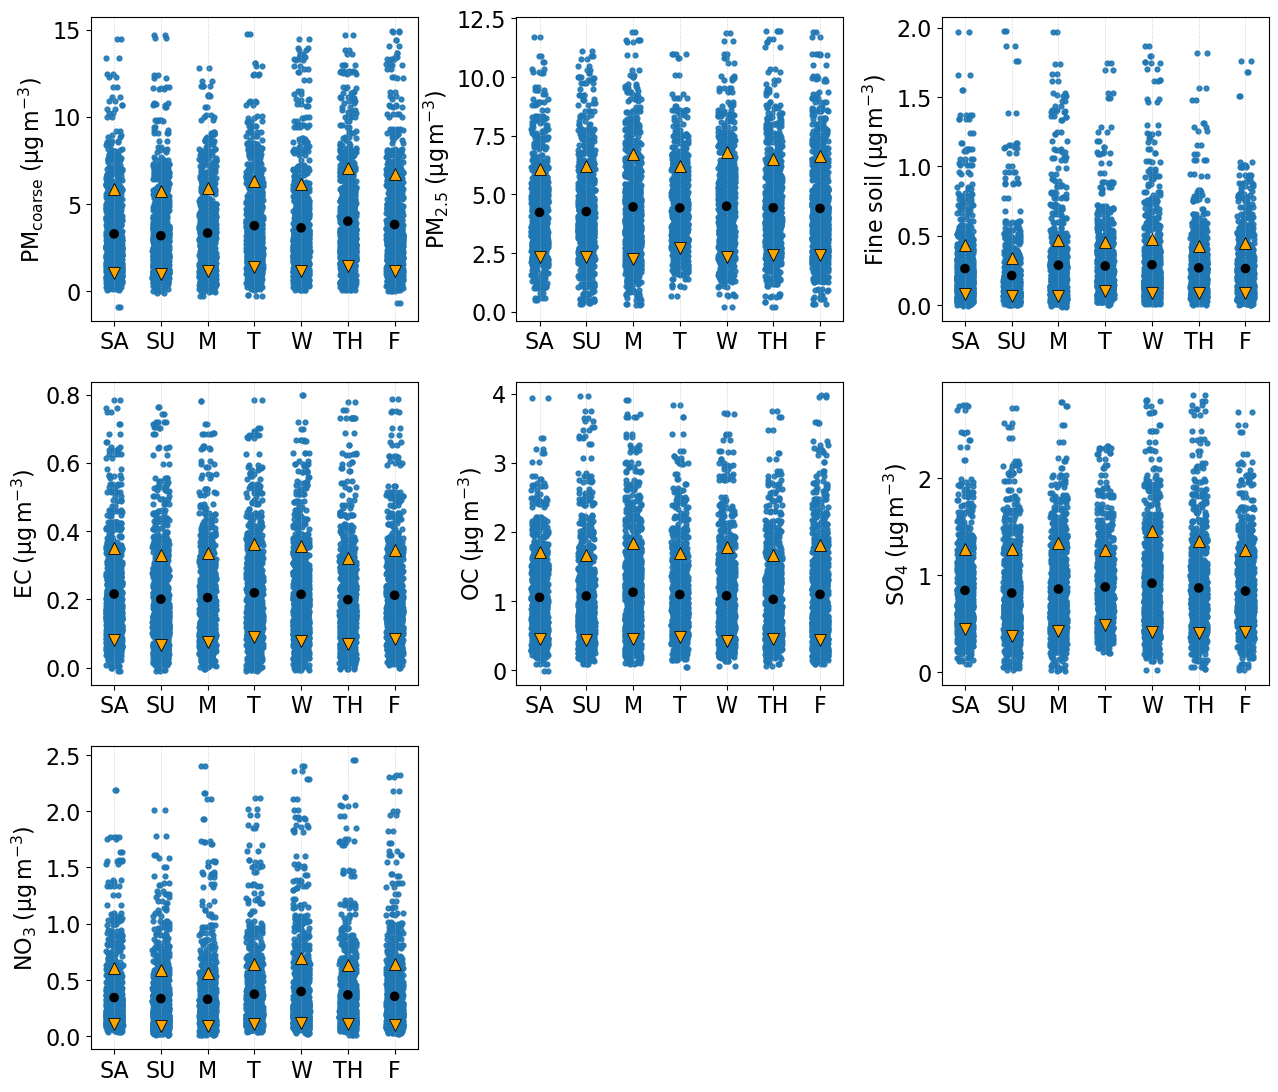

In [6]:
# file: plots/weekday_points_grid.py
from __future__ import annotations

from math import ceil, sqrt
from typing import Optional, Sequence, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["mathtext.default"] = "rm"

# --- Inputs you provided ------------------------------------------------------
target_sites = [
    "Brigantine NWR",
    "Dolly Sods Wilderness",
    "James River Face Wilderness",
    "Shenandoah NP",
    "Swanquarter",
    "Cape Romain NWR",
]

variables = {
    "CM_calculated_Val": r"$\mathrm{PM_{coarse}}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "RCFM_Val":          r"$\mathrm{PM_{2.5}}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "SOILf_Val":         r"$\mathrm{Fine\ soil}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "ECf_Val":           r"$\mathrm{EC}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "OCf_Val":           r"$\mathrm{OC}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "SO4f_Val":          r"$\mathrm{SO_{4}}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "NO3f_Val":          r"$\mathrm{NO_{3}}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
}
# -----------------------------------------------------------------------------

DEFAULT_DAYS_ORDER: tuple[str, ...] = (
    "Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"
)
SHORT_DAY = {
    "Saturday": "SA", "Sunday": "SU", "Monday": "M",
    "Tuesday": "T", "Wednesday": "W", "Thursday": "TH", "Friday": "F"
}

# Column labels for y-axes (use your variables dict)
COLUMN_LABELS = variables.copy()

SITE_COL_CANDIDATES = ["Local Site Name", "SiteName", "site", "Site"]
DATE_COL_CANDIDATES = ["Date Local", "Date", "Sample Date", "Datetime", "datetime", "Time_Start"]


def _detect_col(df: pd.DataFrame, candidates: List[str]) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"None of {candidates} found in DataFrame.")


def _weekday_series(df: pd.DataFrame, time_col: str) -> pd.Series:
    if time_col not in df.columns:
        raise ValueError(f"Column '{time_col}' not found in DataFrame.")
    return pd.to_datetime(df[time_col], errors="coerce").dt.day_name()


def _safe_set_text(setter, text: str):
    try:
        setter(text)
    except Exception:
        setter(text.replace("$", "").replace(r"\mathrm", "").replace(r"\mu", "µ"))  # minimal fallback


def plot_weekday_points_grid(
    df: pd.DataFrame,
    columns: Sequence[str],
    *,
    time_col: str,
    days_order: Optional[Sequence[str]] = None,
    jitter: float = 0.18,
    seed: Optional[int] = 42,
    max_cols: Optional[int] = None,
    figsize_per: tuple[float, float] = (4.2, 4),
    point_size: float = 12.0,
    alpha: float = 0.9,
    show_titles: bool = False,
    ylabels: str = "all",            # 'all' | 'left' | 'none'
    xlabel_rotation: int = 45,
    xlabel_size: int = 16,
    ytick_size: Optional[int] = None,
    ylabel_size: Optional[int] = None,
    # spacing controls
    wspace: float = 0.08,
    hspace: float = 0.05,
    left: float = 0.06,
    right: float = 0.99,
    top: float = 0.92,
    bottom: float = 0.06,
    title: str = "",
    use_iqr: bool = True,            # mean + IQR markers
    # CI options
    ci_type: str = "z",              # 'z' or 'percentile'
    ci_z: float = 1.96,              # for ci_type='z'
    ci_percentiles: tuple[float, float] = (2.5, 97.5),  # for ci_type='percentile'
    ci_as_triangles: bool = True,    # triangles at endpoints; set False to draw errorbar when ci_type='z'
) -> None:
    days_order = tuple(days_order) if days_order is not None else DEFAULT_DAYS_ORDER

    missing = [c for c in columns if c not in df.columns]
    present = [c for c in columns if c in df.columns]
    if not present:
        raise ValueError("None of the requested columns exist in the DataFrame.")
    if missing:
        print(f"Warning: skipping missing columns: {missing}")

    weekdays = _weekday_series(df, time_col)
    pos_map = {d: i for i, d in enumerate(days_order)}

    n = len(present)
    ncols = max(1, int(ceil(sqrt(n)))) if max_cols is None else max(1, int(max_cols))
    nrows = int(ceil(n / ncols))

    fig_w = max(6.0, ncols * figsize_per[0])
    fig_h = max(4.0, nrows * figsize_per[1])
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(fig_w, fig_h),
        gridspec_kw={"wspace": wspace, "hspace": hspace}
    )
    axes_arr = np.atleast_1d(axes).ravel()

    tick_locs = list(range(len(days_order)))
    short_labels = [SHORT_DAY.get(d, d) for d in days_order]

    rows_to_label = {nrows - 1}
    if nrows >= 2 and (n % ncols != 0):
        rows_to_label.add(nrows - 2)

    if ytick_size is None:
        ytick_size = xlabel_size
    if ylabel_size is None:
        ylabel_size = xlabel_size

    for idx, col in enumerate(present):
        ax = axes_arr[idx]
        mask = weekdays.notna() & df[col].notna() & weekdays.isin(days_order)

        label_text = COLUMN_LABELS.get(col, col)

        if not mask.any():
            target = ax.set_title if show_titles else ax.set_ylabel
            _safe_set_text(target, label_text)
            ax.yaxis.label.set_fontsize(ylabel_size)
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.tick_params(axis="y", labelsize=ytick_size)
            continue

        x_base = weekdays[mask].map(pos_map).to_numpy()
        rng = np.random.default_rng(None if seed is None else (int(seed) + idx))
        x = x_base + rng.uniform(-jitter, jitter, size=x_base.size)
        y = df.loc[mask, col].astype(float).to_numpy()

        # raw points
        ax.scatter(x, y, s=point_size, alpha=alpha)

        # mean + IQR markers at same x
        stats_df = pd.DataFrame({"pos": x_base, "y": y})
        grp = stats_df.groupby("pos", sort=True)["y"]

        x_pos = grp.mean().index.to_numpy()
        means = grp.mean().to_numpy()

        # Mean marker (red circle)
        ax.scatter(x_pos, means, s=point_size * 4, marker="o",
                   color="k", edgecolors="none", alpha=1.0, zorder=15)

        if use_iqr:
            q1 = grp.quantile(0.25).to_numpy()
            q3 = grp.quantile(0.75).to_numpy()
            ok = np.isfinite(q1) & np.isfinite(q3)
            # IQR endpoints: green triangles exactly at Q1 (down) and Q3 (up)
            ax.scatter(x_pos[ok], q1[ok], s=point_size * 6, marker="v",
                       color="orange", edgecolors="k", linewidths=0.6, alpha=1.0, zorder=15)
            ax.scatter(x_pos[ok], q3[ok], s=point_size * 6, marker="^",
                       color="orange", edgecolors="k", linewidths=0.6, alpha=1.0, zorder=15)
        
        else:
            if ci_type.lower() == "percentile":
                # empirical CI endpoints (e.g., 2.5% and 97.5%) across raw data
                p_lo, p_hi = ci_percentiles
                qlo = grp.quantile(p_lo / 100.0).to_numpy()
                qhi = grp.quantile(p_hi / 100.0).to_numpy()
                ok = np.isfinite(qlo) & np.isfinite(qhi) & (qhi >= qlo)
                ax.scatter(x_pos[ok], qlo[ok], s=point_size * 6, marker="v",
                           color="orange", edgecolors="k", linewidths=0.6, alpha=1.0, zorder=15)
                ax.scatter(x_pos[ok], qhi[ok], s=point_size * 6, marker="^",
                           color="orange", edgecolors="k", linewidths=0.6, alpha=1.0, zorder=15)
            else:
                # z·SE CI around the mean
                ci = ci_z * se_i
                ok = np.isfinite(means) & np.isfinite(ci) & (ci >= 0)
                if np.any(ok):
                    if ci_as_triangles:
                        low = means - ci
                        high = means + ci
                        ax.scatter(x_pos[ok], low[ok], s=point_size * 6, marker="v",
                                   color="orange", edgecolors="k", linewidths=0.6, alpha=1.0, zorder=15)
                        ax.scatter(x_pos[ok], high[ok], s=point_size * 6, marker="^",
                                   color="orange", edgecolors="k", linewidths=0.6, alpha=1.0, zorder=15)
                    else:
                        yerr = np.vstack([ci[ok], ci[ok]])
                        ax.errorbar(x_pos[ok], means[ok], yerr=yerr,
                                    fmt="none", ecolor="orange", elinewidth=1.6,
                                    capsize=4, capthick=1.2, zorder=10)        

        ax.set_xlim(-0.5, len(days_order) - 0.5)
        ax.set_xticks(tick_locs)
        ax.set_xticklabels(short_labels, rotation=xlabel_rotation, fontsize=xlabel_size)
        row = idx // ncols
        '''if row in rows_to_label:
            ax.set_xticklabels(short_labels, rotation=xlabel_rotation, fontsize=xlabel_size)
        else:
            ax.set_xticklabels([])'''

        ax.grid(True, axis="x", linestyle=":", linewidth=0.7, alpha=0.6)

        if ylabels == "all" or (ylabels == "left" and idx % ncols == 0):
            _safe_set_text(ax.set_ylabel, label_text)
            ax.yaxis.label.set_fontsize(ylabel_size)
        ax.tick_params(axis="y", labelsize=ytick_size)

        if show_titles:
            _safe_set_text(ax.set_title, label_text)

    # hide unused slots
    for j in range(n, len(axes_arr)):
        axes_arr[j].axis("off")

    if title:
        fig.suptitle(title, y=top + 0.02)
    fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom)
    #fig.text(0.5, 0.01, "Day of the Week", ha="center", fontsize=16)
    plt.show()


# ---------------- Runner for your IMPROVE DF ----------------
def plot_improve_weekday_raw_mean_iqr(
    IMPROVE: pd.DataFrame,
    *,
    target_sites: list[str],
    variables: dict[str, str],
    max_cols: int = 3,
) -> None:
    """Filter to target sites, keep requested variables, and plot raw + mean/IQR."""
    site_col = _detect_col(IMPROVE, SITE_COL_CANDIDATES)
    date_col = _detect_col(IMPROVE, DATE_COL_CANDIDATES)

    df_sel = IMPROVE.loc[IMPROVE[site_col].isin(target_sites)].copy()
    if df_sel.empty:
        raise ValueError("No rows matched target_sites. Check names and site column.")

    cols_present = [c for c in variables.keys() if c in df_sel.columns]
    if not cols_present:
        raise ValueError("None of the requested species columns were found in the DataFrame.")

    # Plot
    plot_weekday_points_grid(
        df_sel,
        columns=cols_present,
        time_col=date_col,           # use detected date column
        max_cols=max_cols,
        xlabel_rotation=0, xlabel_size=16,
        ytick_size=16, ylabel_size=16,
        wspace=0.3, hspace=0.2,
        left=0.06, right=0.995, top=0.92, bottom=0.06,
        show_titles=False, ylabels="all",
        title="",
        use_iqr=False, ci_type="percentile", ci_percentiles=(15, 85)
    )


# ---------------- Example call (uncomment to run) ----------------
plot_improve_weekday_raw_mean_iqr(
     IMPROVE,
     target_sites=target_sites,
     variables=variables,
     max_cols=3,
 )




In [7]:
# path: analysis/simple_availability_2018_2022.py
import pandas as pd

# --- inputs ---
# Assumes IMPROVE DataFrame exists with columns: Date, SiteName, plus numeric variables.

target_sites = [
    "Brigantine NWR",
    "Dolly Sods Wilderness",
    "James River Face Wilderness",
    "Shenandoah NP",
    "Swanquarter",
    "Cape Romain NWR",
]

# --- simple percent non-NaN ---
df = IMPROVE.copy()  # type: ignore[name-defined]
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df[df["Date"].between("2018-01-01", "2022-12-31") & df["SiteName"].isin(target_sites)]

# numeric variables only (drop obvious numeric meta if present)
value_cols = df.select_dtypes("number").columns.tolist()
for meta in ["Latitude", "Longitude", "Year", "Month", "Week"]:
    if meta in value_cols:
        value_cols.remove(meta)

# % available by site & variable
pct_by_site_col = (
    df.groupby("SiteName")[value_cols]
      .apply(lambda g: g.notna().mean() * 100)
      .reindex(target_sites)
      .round(2)
)

# overall % per site (mean across variables)
overall = pct_by_site_col.mean(axis=1).rename("pct_available_overall").to_frame().round(2)

print("Overall % available per site (2018–2022):")
print(overall.to_string())

print("\nBy-variable % available (2018–2022):")
print(pct_by_site_col.to_string())


Overall % available per site (2018–2022):
                             pct_available_overall
SiteName                                          
Brigantine NWR                               65.74
Dolly Sods Wilderness                        73.21
James River Face Wilderness                  73.39
Shenandoah NP                                72.36
Swanquarter                                  35.45
Cape Romain NWR                              71.50

By-variable % available (2018–2022):
                               POC  AuxID  EPACode  ALf_Val  ALf_MDL  ammNO3f_Val  ammNO3f_MDL  ammSO4f_Val  ammSO4f_MDL  ASf_Val  ASf_MDL  BRf_Val  BRf_MDL  CAf_Val  CAf_MDL  EC1f_Val  EC1f_MDL  EC2f_Val  EC2f_MDL  EC3f_Val  EC3f_MDL  ECf_Val  ECf_MDL  OC1f_Val  OC1f_MDL  OC2f_Val  OC2f_MDL  OC3f_Val  OC3f_MDL  OC4f_Val  OC4f_MDL  OMCf_Val  OMCf_MDL  OPf_Val  OPf_MDL  OPTf_Val  OPTf_MDL  OCf_Val  OCf_MDL  TCf_Val  TCf_MDL  CHLf_Val  CHLf_MDL  CLf_Val  CLf_MDL  CRf_Val  CRf_MDL  CUf_Val  CUf_MDL  fAbs_Val  

In [8]:
# Simple: percent availability per species (2018–2022) for selected sites
import pandas as pd

# --- inputs ---
target_sites = [
    "Brigantine NWR",
    "Dolly Sods Wilderness",
    "James River Face Wilderness",
    "Shenandoah NP",
    "Swanquarter",
    "Cape Romain NWR",
]

species = [
    "CM_calculated_Val",
    "RCFM_Val",
    "SOILf_Val",
    "ECf_Val",
    "OCf_Val",
    "SO4f_Val",
    "NO3f_Val",
]

# --- filter period & sites ---
df = IMPROVE.copy()  # assumes IMPROVE is already in memory
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df[df["Date"].between("2018-01-01", "2022-12-31") & df["SiteName"].isin(target_sites)]

# Keep only species columns that exist (why: different datasets may miss some)
present = [c for c in species if c in df.columns]
if not present:
    raise KeyError("None of the requested species columns are present in IMPROVE.")

# % non-NaN by site × species
pct_by_site_species = (
    df.groupby("SiteName")[present]
      .apply(lambda g: g.notna().mean() * 100)
      .reindex(target_sites)   # keep requested site order
      .round(2)
)

# Overall % per species across all selected sites (2018–2022)
pct_overall_species = (df[present].notna().mean() * 100).round(2)
pct_overall_species.name = "pct_overall"

print("\n% non-NaN by site × species (2018–2022):")
print(pct_by_site_species.to_string())

print("\n% non-NaN overall per species (2018–2022):")
print(pct_overall_species.to_string())

# If you prefer DataFrames to reuse:
# pct_by_site_species  -> DataFrame: index=SiteName, columns=species
# pct_overall_species  -> Series: index=species



% non-NaN by site × species (2018–2022):
                             CM_calculated_Val  RCFM_Val  SOILf_Val  ECf_Val  OCf_Val  SO4f_Val  NO3f_Val
SiteName                                                                                                 
Brigantine NWR                           82.59     82.59      87.52    84.40    85.22     86.54     84.40
Dolly Sods Wilderness                    97.21     88.01      96.72    96.22    96.06     88.01     89.16
James River Face Wilderness              96.22     95.24      96.39    94.25    94.91     96.39     95.89
Shenandoah NP                            95.57     94.25      95.07    94.75    94.58     94.58     94.91
Swanquarter                              39.49     43.84      43.60    44.42    44.42     44.75     44.75
Cape Romain NWR                          93.27     91.63      90.80    92.78    92.78     93.76     93.76

% non-NaN overall per species (2018–2022):
CM_calculated_Val    77.69
RCFM_Val             77.06
SOILf_Val   

In [9]:
# Input list
target_sites = [
    "Brigantine NWR",
    "Dolly Sods Wilderness",
    "James River Face Wilderness",
    "Shenandoah NP",
    "Swanquarter",
    "Cape Romain NWR",
]

# Detect site-name column
SITE_COL_CANDIDATES = ["Local Site Name", "SiteName", "site", "Site"]
try:
    site_col = next(c for c in SITE_COL_CANDIDATES if c in IMPROVE.columns)
except StopIteration:
    raise ValueError(f"Could not find a site name column in {SITE_COL_CANDIDATES}")

# Case-insensitive, trimmed match (preserves original values)
norm_sites = pd.Series(target_sites, dtype=str).str.strip().str.casefold().tolist()
mask = (
    IMPROVE[site_col]
    .astype(str)
    .str.strip()
    .str.casefold()
    .isin(norm_sites)
)

IMPROVE_targets = IMPROVE.loc[mask].copy().reset_index(drop=True)

# Optional: quick sanity check
print(f"Extracted rows: {len(IMPROVE_targets):,} across {IMPROVE_targets[site_col].nunique()} sites")


Extracted rows: 8,526 across 6 sites


In [10]:
IMPROVE_targets

,Dataset,SiteCode,POC,Date,AuxID,SiteName,Latitude,Longitude,State,EPACode,...,Sf_MDL,TIf_Val,TIf_MDL,Vf_Val,Vf_MDL,ZNf_Val,ZNf_MDL,ZRf_Val,ZRf_MDL,region
0,IMPAER,ROMA1,1,2018-01-02,0,Cape Romain NWR,32.941,-79.6572,SC,450190046,...,0.00033,0.00143,0.00033,0.00001,0.00011,0.00369,0.00022,0.00112,0.00133,SE
1,IMPAER,ROMA1,1,2018-01-05,0,Cape Romain NWR,32.941,-79.6572,SC,450190046,...,0.00033,0.00134,0.00033,0.00050,0.00011,0.00877,0.00022,0.00072,0.00132,SE
2,IMPAER,ROMA1,1,2018-01-08,0,Cape Romain NWR,32.941,-79.6572,SC,450190046,...,0.00033,0.00064,0.00033,0.00013,0.00011,0.00269,0.00022,-0.00037,0.00131,SE
3,IMPAER,ROMA1,1,2018-01-11,0,Cape Romain NWR,32.941,-79.6572,SC,450190046,...,0.00032,0.00010,0.00032,0.00006,0.00011,0.00025,0.00021,0.00022,0.00129,SE
4,IMPAER,ROMA1,1,2018-01-14,0,Cape Romain NWR,32.941,-79.6572,SC,450190046,...,0.00033,0.00090,0.00033,0.00003,0.00011,0.00300,0.00022,0.00061,0.00130,SE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8521,IMPAER,SWAN1,2,2022-12-19,0,Swanquarter,35.451,-76.2075,NC,370959000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E
8522,IMPAER,SWAN1,2,2022-12-22,0,Swanquarter,35.451,-76.2075,NC,370959000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E
8523,IMPAER,SWAN1,2,2022-12-25,0,Swanquarter,35.451,-76.2075,NC,370959000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E
8524,IMPAER,SWAN1,2,2022-12-28,0,Swanquarter,35.451,-76.2075,NC,370959000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E


In [11]:
unique_days = IMPROVE_targets['Date'].dt.date.drop_duplicates()
day_counts = pd.Series(unique_days).apply(lambda x: pd.Timestamp(x).day_name()).value_counts()

print("Number of occurrences for each day of the week:")
print(day_counts)

Number of occurrences for each day of the week:
Date
Tuesday      87
Friday       87
Monday       87
Thursday     87
Sunday       87
Wednesday    87
Saturday     87
Name: count, dtype: int64


In [12]:
# Count datapoints per weekday in IMPROVE_targets (Sat→Fri order)

import pandas as pd

# Use whichever exists: IMPROVE_targets or IMPROVE_target
try:
    df_targets = IMPROVE_targets
except NameError:
    df_targets = IMPROVE_target  # if your variable is singular

# Detect a date column
for _c in ["Date", "Date Local", "Sample Date", "Datetime", "datetime"]:
    if _c in df_targets.columns:
        date_col = _c
        break
else:
    raise ValueError("No date column found (looked for: Date, Date Local, Sample Date, Datetime, datetime).")

# Weekday counts
DAYS_ORDER = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
SHORT_DAY = {"Saturday":"SA","Sunday":"SU","Monday":"M","Tuesday":"T","Wednesday":"WE","Thursday":"TH","Friday":"F"}

weekday = pd.to_datetime(df_targets[date_col], errors="coerce").dt.day_name()
counts = weekday.value_counts().reindex(DAYS_ORDER, fill_value=0)

# Nice table
counts_df = counts.rename_axis("Weekday").reset_index(name="datapoints")
counts_df["short"] = counts_df["Weekday"].map(SHORT_DAY)
counts_df = counts_df[["Weekday", "short", "datapoints"]]

print("Datapoints per weekday (combined across selected sites):")
print(counts_df.to_string(index=False))


Datapoints per weekday (combined across selected sites):
  Weekday short  datapoints
 Saturday    SA        1218
   Sunday    SU        1218
   Monday     M        1218
  Tuesday     T        1218
Wednesday    WE        1218
 Thursday    TH        1218
   Friday     F        1218


In [13]:
# assumes IMPROVE is already loaded as a DataFrame
winter_months = {12, 1, 2, 3, 4}

df = IMPROVE.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])  # why: ensure month extraction works

df_winter = df[df["Date"].dt.month.isin(winter_months)].copy()

# Optional: define a "WinterYear" so Dec belongs to the next year's winter
# m = df_winter["Date"].dt.month
# df_winter["WinterYear"] = df_winter["Date"].dt.year + (m == 12).astype(int)

# Optional: filter to specific sites
# target_sites = ["Brigantine NWR","Swanquarter","Cape Romain NWR"]
# df_winter = df_winter[df_winter["SiteName"].isin(target_sites)]

print(df_winter.shape)
df_winter.head()


(9534, 225)


,Dataset,SiteCode,POC,Date,AuxID,SiteName,Latitude,Longitude,State,EPACode,...,Sf_MDL,TIf_Val,TIf_MDL,Vf_Val,Vf_MDL,ZNf_Val,ZNf_MDL,ZRf_Val,ZRf_MDL,region
0,IMPAER,ATLA1,1,2018-01-02,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE
1,IMPAER,ATLA1,1,2018-01-05,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE
2,IMPAER,ATLA1,1,2018-01-08,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE
3,IMPAER,ATLA1,1,2018-01-11,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE
4,IMPAER,ATLA1,1,2018-01-14,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE


In [14]:
df_winter

,Dataset,SiteCode,POC,Date,AuxID,SiteName,Latitude,Longitude,State,EPACode,...,Sf_MDL,TIf_Val,TIf_MDL,Vf_Val,Vf_MDL,ZNf_Val,ZNf_MDL,ZRf_Val,ZRf_MDL,region
0,IMPAER,ATLA1,1,2018-01-02,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE
1,IMPAER,ATLA1,1,2018-01-05,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE
2,IMPAER,ATLA1,1,2018-01-08,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE
3,IMPAER,ATLA1,1,2018-01-11,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE
4,IMPAER,ATLA1,1,2018-01-14,0,South Dekalb,33.688,-84.2903,GA,130890002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22945,IMPAER,SWAN1,2,2022-12-19,0,Swanquarter,35.451,-76.2075,NC,370959000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E
22946,IMPAER,SWAN1,2,2022-12-22,0,Swanquarter,35.451,-76.2075,NC,370959000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E
22947,IMPAER,SWAN1,2,2022-12-25,0,Swanquarter,35.451,-76.2075,NC,370959000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E
22948,IMPAER,SWAN1,2,2022-12-28,0,Swanquarter,35.451,-76.2075,NC,370959000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E


In [15]:
# Drop all columns ending with "_MDL"
IMPROVE_filtered = IMPROVE.drop(columns=[col for col in IMPROVE.columns if col.endswith("_MDL")])

# Ensure no division by zero issues
'''IMPROVE_filtered["Pb_Zn_Ratio"] = IMPROVE_filtered["PBf_Val"] / (IMPROVE_filtered["PBf_Val"] + IMPROVE_filtered["ZNf_Val"])

IMPROVE_filtered["Fine_EC"] = IMPROVE_filtered["RCFM_Val"] - IMPROVE_filtered["ECf_Val"]

IMPROVE_filtered["Fine_ECSoil"] = IMPROVE_filtered["RCFM_Val"] - (IMPROVE_filtered["ECf_Val"]+IMPROVE_filtered["SOILf_Val"])

# Handle cases where both PBf_Val and ZNf_Val are zero (to avoid NaN)
#IMPROVE_filtered["Pb_Zn_Ratio"] = IMPROVE_filtered["Pb_Zn_Ratio"]

IMPROVE_filtered'''

'IMPROVE_filtered["Pb_Zn_Ratio"] = IMPROVE_filtered["PBf_Val"] / (IMPROVE_filtered["PBf_Val"] + IMPROVE_filtered["ZNf_Val"])\n\nIMPROVE_filtered["Fine_EC"] = IMPROVE_filtered["RCFM_Val"] - IMPROVE_filtered["ECf_Val"]\n\nIMPROVE_filtered["Fine_ECSoil"] = IMPROVE_filtered["RCFM_Val"] - (IMPROVE_filtered["ECf_Val"]+IMPROVE_filtered["SOILf_Val"])\n\n# Handle cases where both PBf_Val and ZNf_Val are zero (to avoid NaN)\n#IMPROVE_filtered["Pb_Zn_Ratio"] = IMPROVE_filtered["Pb_Zn_Ratio"]\n\nIMPROVE_filtered'

In [16]:
'''import pandas as pd
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.styles import Font

# Step 1: Copy and preprocess
IMPROVE_filtee = IMPROVE_filtered.copy()
IMPROVE_filtee['Date'] = pd.to_datetime(IMPROVE_filtee['Date'])

# Define target sites
target_sites = [
    "Brigantine NWR", 
    "Dolly Sods Wilderness",
    "James River Face Wilderness", 
    "Shenandoah NP",
    "Swanquarter",
    "Cape Romain NWR"
]

# Filter data
df = IMPROVE_filtee[IMPROVE_filtee["SiteName"].isin(target_sites)].copy()

# Define seasons
def get_season(row):
    m, y = row['Date'].month, row['Date'].year
    if m in [12, 1, 2, 3, 4] and y in [2020, 2021, 2022]:
        return 'Winter'
    elif m in [5, 6] and y in [2021, 2022]:
        return 'Summer'
    elif m in [8, 9] and y == 2020:
        return 'Fall'
    return None

df['Season'] = df.apply(get_season, axis=1)
df = df[df['Season'].notna()]
df['NO3f_Val'] = pd.to_numeric(df['NO3f_Val'], errors='coerce')

# Step 2: Compute stats
results = []

for site in target_sites:
    site_data = df[df['SiteName'] == site]
    lat = site_data['Latitude'].iloc[0] if 'Latitude' in site_data.columns else None
    lon = site_data['Longitude'].iloc[0] if 'Longitude' in site_data.columns else None

    for season in ['Winter', 'Summer', 'Fall']:
        vals = site_data[site_data['Season'] == season]['NO3f_Val'].dropna()
        if len(vals) == 0:
            continue
        results.append({
            'Site': site,
            'Season': season,
            'Latitude': lat,
            'Longitude': lon,
            'Count': len(vals),
            'Min': vals.min(),
            'Max': vals.max(),
            'Mean': vals.mean(),
            'Median': vals.median(),
            'Std': vals.std(),
            '25th': vals.quantile(0.25),
            '75th': vals.quantile(0.75)
        })

stats_df = pd.DataFrame(results)

# Step 3: Export to Excel
wb = Workbook()
ws = wb.active
ws.title = "NO3f Seasonal Stats"

# Write data
for r_idx, row in enumerate(dataframe_to_rows(stats_df, index=False, header=True), 1):
    for c_idx, value in enumerate(row, 1):
        ws.cell(row=r_idx, column=c_idx, value=value)
        if r_idx == 1:
            ws.cell(row=r_idx, column=c_idx).font = Font(bold=True)

# Autofit column width
for col in ws.columns:
    max_len = max(len(str(cell.value)) if cell.value else 0 for cell in col)
    col_letter = col[0].column_letter
    ws.column_dimensions[col_letter].width = max_len + 2

# Save file
wb.save("C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/IMPROVE_NO3f_SeasonalStats_with_LatLon.xlsx")'''


'import pandas as pd\nfrom openpyxl import Workbook\nfrom openpyxl.utils.dataframe import dataframe_to_rows\nfrom openpyxl.styles import Font\n\n# Step 1: Copy and preprocess\nIMPROVE_filtee = IMPROVE_filtered.copy()\nIMPROVE_filtee[\'Date\'] = pd.to_datetime(IMPROVE_filtee[\'Date\'])\n\n# Define target sites\ntarget_sites = [\n    "Brigantine NWR", \n    "Dolly Sods Wilderness",\n    "James River Face Wilderness", \n    "Shenandoah NP",\n    "Swanquarter",\n    "Cape Romain NWR"\n]\n\n# Filter data\ndf = IMPROVE_filtee[IMPROVE_filtee["SiteName"].isin(target_sites)].copy()\n\n# Define seasons\ndef get_season(row):\n    m, y = row[\'Date\'].month, row[\'Date\'].year\n    if m in [12, 1, 2, 3, 4] and y in [2020, 2021, 2022]:\n        return \'Winter\'\n    elif m in [5, 6] and y in [2021, 2022]:\n        return \'Summer\'\n    elif m in [8, 9] and y == 2020:\n        return \'Fall\'\n    return None\n\ndf[\'Season\'] = df.apply(get_season, axis=1)\ndf = df[df[\'Season\'].notna()]\ndf[\'N

In [17]:
IMPROVE_filtered.loc[IMPROVE_filtered["OCf_Val"] > 5, "OCf_Val"] = np.nan
IMPROVE_filtered.loc[IMPROVE_filtered["ECf_Val"] > 2, "ECf_Val"] = np.nan
IMPROVE_filtered.loc[IMPROVE_filtered["SOILf_Val"] > 5, "SOILf_Val"] = np.nan


In [18]:
# Convert to datetime if not already
'''IMPROVE_filtered['Date'] = pd.to_datetime(IMPROVE_filtered['Date'], errors='coerce')

# Define winter months and years of interest
winter_months = [12, 1, 2, 3, 4]
valid_years = [2018, 2019, 2020, 2021, 2022]

# Extract winter data in one step
IMPROVE_filteredd = IMPROVE_filtered[
    (IMPROVE_filtered['Date'].dt.year.isin(valid_years)) &
    (IMPROVE_filtered['Date'].dt.month.isin(winter_months))
]
IMPROVE_filteredd'''

"IMPROVE_filtered['Date'] = pd.to_datetime(IMPROVE_filtered['Date'], errors='coerce')\n\n# Define winter months and years of interest\nwinter_months = [12, 1, 2, 3, 4]\nvalid_years = [2018, 2019, 2020, 2021, 2022]\n\n# Extract winter data in one step\nIMPROVE_filteredd = IMPROVE_filtered[\n    (IMPROVE_filtered['Date'].dt.year.isin(valid_years)) &\n    (IMPROVE_filtered['Date'].dt.month.isin(winter_months))\n]\nIMPROVE_filteredd"

In [19]:
# Extract unique dates (ignore time) and convert to day names
'''unique_days = IMPROVE_filtered['Date'].dt.date.drop_duplicates()
day_counts = pd.Series(unique_days).apply(lambda x: pd.Timestamp(x).day_name()).value_counts()

print("Number of occurrences for each day of the week:")
print(day_counts)'''


'unique_days = IMPROVE_filtered[\'Date\'].dt.date.drop_duplicates()\nday_counts = pd.Series(unique_days).apply(lambda x: pd.Timestamp(x).day_name()).value_counts()\n\nprint("Number of occurrences for each day of the week:")\nprint(day_counts)'

In [20]:
# Count the number of occurrences of each weekday, excluding NaNs
'''IMPROVE_filte = IMPROVE_filtered.copy()
IMPROVE_filte['Weekday'] = IMPROVE_filte['Date'].dt.day_name()
weekday_counts = IMPROVE_filte['Weekday'].value_counts(dropna=True).reset_index()
weekday_counts.columns = ['Weekday', 'Count']

# Print the result
print("Number of occurrences of each weekday (excluding NaNs):")
print(weekday_counts)'''


'IMPROVE_filte = IMPROVE_filtered.copy()\nIMPROVE_filte[\'Weekday\'] = IMPROVE_filte[\'Date\'].dt.day_name()\nweekday_counts = IMPROVE_filte[\'Weekday\'].value_counts(dropna=True).reset_index()\nweekday_counts.columns = [\'Weekday\', \'Count\']\n\n# Print the result\nprint("Number of occurrences of each weekday (excluding NaNs):")\nprint(weekday_counts)'

In [21]:
IMPROVE_filtered["SiteName"].unique()

array(['South Dekalb', 'Chassahowitzka NWR', 'Cohutta', 'Everglades NP',
       'Linville Gorge', 'Okefenokee NWR', 'Cape Romain NWR', 'St. Marks',
       'Shining Rock Wilderness', 'Swanquarter', 'Brigantine NWR',
       'Dolly Sods Wilderness', 'Frostburg Reservoir (Big Piney Run)',
       'James River Face Wilderness', 'Shenandoah NP'], dtype=object)

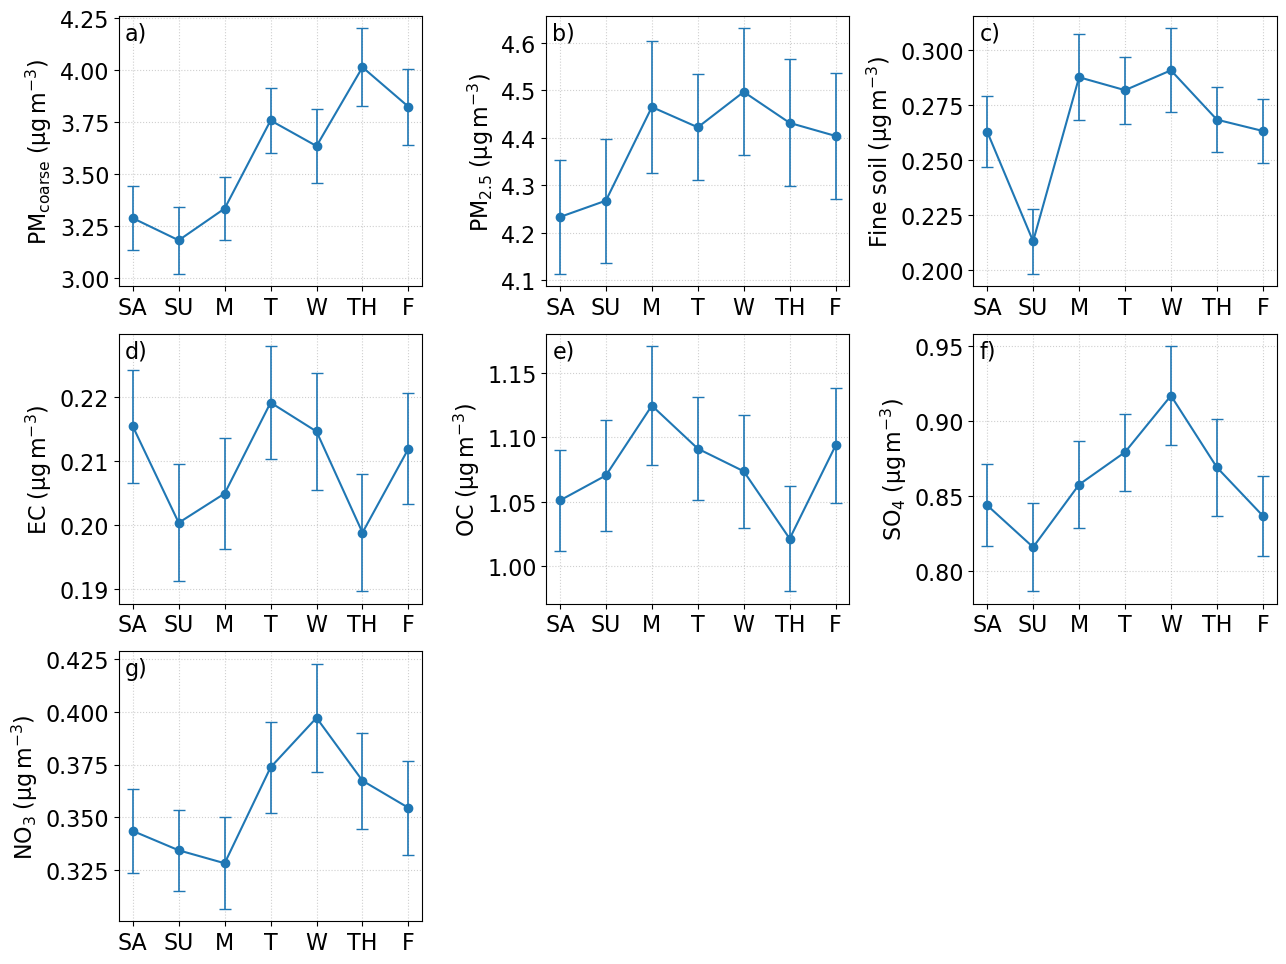

In [22]:
# file: plots/weekly_species_separate.py
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil
from typing import List, Dict
import string

plt.rcParams["mathtext.default"] = "rm"

target_sites = [
    "Brigantine NWR","Dolly Sods Wilderness","James River Face Wilderness",
    "Shenandoah NP","Swanquarter","Cape Romain NWR",
]

variables = {
    "CM_calculated_Val": r"$\mathrm{PM_{coarse}}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "RCFM_Val":          r"$\mathrm{PM_{2.5}}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "SOILf_Val":         r"$\mathrm{Fine\ soil}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "ECf_Val":           r"$\mathrm{EC}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "OCf_Val":           r"$\mathrm{OC}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "SO4f_Val":          r"$\mathrm{SO_{4}}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
    "NO3f_Val":          r"$\mathrm{NO_{3}}\;(\mu\mathrm{g}\,\mathrm{m}^{-3})$",
}

days_order = ["Saturday","Sunday","Monday","Tuesday","Wednesday","Thursday","Friday"]
SHORT_DAY = {"Saturday":"SA","Sunday":"SU","Monday":"M","Tuesday":"T","Wednesday":"W","Thursday":"TH","Friday":"F"}
short_labels = [SHORT_DAY[d] for d in days_order]

SITE_COL_CANDIDATES = ["Local Site Name","SiteName","site","Site"]
DATE_COL_CANDIDATES = ["Date Local","Date","Sample Date","Datetime","datetime"]

ZCRIT = 1.96
USE_ERRORBARS = True

ncols = 3
xlabel = "Day of Week"
ylabel_fontsize = 16
xtick_size = 16
ytick_size = 16
xlabel_size = 16
title = ""

def _detect_col(df: pd.DataFrame, candidates: List[str]) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"None of the candidate columns found: {candidates}")

def _weekly_stats_for_var(df: pd.DataFrame, date_col: str, value_col: str) -> pd.DataFrame:
    work = df[[date_col, value_col]].copy()
    work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
    work[value_col] = pd.to_numeric(work[value_col], errors="coerce")
    work = work.dropna(subset=[date_col, value_col])
    work["DayOfWeek"] = work[date_col].dt.day_name()
    work = work[work["DayOfWeek"].isin(days_order)].copy()
    grp = (
        work.groupby("DayOfWeek", observed=True)[value_col]
        .agg(["mean","count","std"])
        .reindex(days_order)
    )
    grp["se"] = np.divide(grp["std"], np.sqrt(grp["count"]),
                          out=np.full_like(grp["std"], np.nan, dtype=float),
                          where=grp["count"] > 1)
    grp["ci95"] = ZCRIT * grp["se"]
    return grp

# --- MAIN (expects IMPROVE DataFrame present) ---
_site_col = _detect_col(IMPROVE_filtered, SITE_COL_CANDIDATES)
_date_col = _detect_col(IMPROVE_filtered, DATE_COL_CANDIDATES)
df_sel = IMPROVE_filtered.loc[IMPROVE_filtered[_site_col].isin(target_sites)].copy()
if df_sel.empty:
    raise ValueError("No rows matched the provided target_sites.")

stats: Dict[str, pd.DataFrame] = {}
for var in variables:
    if var in df_sel.columns:
        stats[var] = _weekly_stats_for_var(df_sel, _date_col, var)

nvars = len(variables)
nrows = ceil(nvars / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.5, nrows*3.6), sharex=True)
axes_arr = np.atleast_1d(axes).ravel()

panel_labels = [f"{c})" for c in string.ascii_lowercase[:nvars]]

for i, (var, label) in enumerate(variables.items()):
    ax = axes_arr[i]
    if var not in stats:
        ax.axis("off"); continue

    dfv = stats[var]
    x = np.arange(len(days_order))
    y = dfv["mean"].to_numpy()
    ok = np.isfinite(y)

    ax.plot(x[ok], y[ok], marker="o")
    if USE_ERRORBARS:
        yerr = dfv["ci95"].to_numpy()
        ax.errorbar(x[ok], y[ok], yerr=yerr[ok], fmt="none", capsize=4, elinewidth=1.2)

    ax.set_ylabel(label, fontsize=ylabel_fontsize)
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.6)
    ax.tick_params(axis="y", labelsize=ytick_size)
    ax.text(0.02, 0.98, panel_labels[i], transform=ax.transAxes, fontsize=16, va="top", ha="left")

    # ticks everywhere but labels only on last and second-to-last rows (force visibility with sharex)
    ax.set_xticks(range(len(days_order)))
    ax.set_xticklabels(short_labels, rotation=0, ha="center", fontsize=xtick_size)
    ax.tick_params(axis="x", labelbottom=True)  # force visible despite sharex
    row = i // ncols
    '''if row in {nrows - 1, max(0, nrows - 2)}:
        ax.set_xticklabels(short_labels, rotation=0, ha="center", fontsize=xtick_size)
        ax.tick_params(axis="x", labelbottom=True)  # force visible despite sharex
        #if row == nrows - 1:
            #ax.set_xlabel(xlabel, fontsize=xlabel_size)
    else:
        ax.set_xticklabels([])
        ax.tick_params(axis="x", labelbottom=False)'''

# Hide any unused axes
for j in range(i + 1, len(axes_arr)):
    axes_arr[j].axis("off")

fig.suptitle(title, y=0.98, fontsize=16)
fig.tight_layout(rect=[0.04, 0.04, 0.99, 0.95])
#fig.text(0.5, 0.01, "Day of the Week", ha="center", fontsize=16)
plt.show()



In [23]:
# Extract coordinates for target sites
'''site_coords = (
    IMPROVE_filtered[IMPROVE_filtered["SiteName"].isin(target_sites)]
    .groupby("SiteName")[["Latitude", "Longitude"]]
    .first()  # Assumes coordinates are constant per site
    .reset_index()
)

print(site_coords)'''


'site_coords = (\n    IMPROVE_filtered[IMPROVE_filtered["SiteName"].isin(target_sites)]\n    .groupby("SiteName")[["Latitude", "Longitude"]]\n    .first()  # Assumes coordinates are constant per site\n    .reset_index()\n)\n\nprint(site_coords)'

In [24]:
# Add weekday name
"""IMPROVE_filtere = IMPROVE_filtered.copy()
IMPROVE_filtere['Weekday'] = IMPROVE_filtere['Date'].dt.day_name()
# Define target sites 
target_sites = [
    "Brigantine NWR", 
    "Dolly Sods Wilderness",
    #"Frostburg Reservoir (Big Piney Run)",  
    "James River Face Wilderness", 
    "Shenandoah NP",
    #"Linville Gorge",
    #"Shining Rock Wilderness",
    "Swanquarter",
    "Cape Romain NWR",
    #"Okefenokee NWR",
    #"Chassahowitzka NWR",
    #"Everglades NP"
]


    # Filter data for the specific locations
df = IMPROVE_filtere[IMPROVE_filtere["SiteName"].isin(target_sites)]

# Group by weekday and compute median for each column
weekday_medians = df.groupby('Weekday').mean(numeric_only=True)

# Optional: Order weekdays
weekday_order = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekday_medians = weekday_medians.reindex(weekday_order)

weekday_medians

weekday_medians.to_excel("C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/GroundTruthall.xlsx")"""


'IMPROVE_filtere = IMPROVE_filtered.copy()\nIMPROVE_filtere[\'Weekday\'] = IMPROVE_filtere[\'Date\'].dt.day_name()\n# Define target sites \ntarget_sites = [\n    "Brigantine NWR", \n    "Dolly Sods Wilderness",\n    #"Frostburg Reservoir (Big Piney Run)",  \n    "James River Face Wilderness", \n    "Shenandoah NP",\n    #"Linville Gorge",\n    #"Shining Rock Wilderness",\n    "Swanquarter",\n    "Cape Romain NWR",\n    #"Okefenokee NWR",\n    #"Chassahowitzka NWR",\n    #"Everglades NP"\n]\n\n\n    # Filter data for the specific locations\ndf = IMPROVE_filtere[IMPROVE_filtere["SiteName"].isin(target_sites)]\n\n# Group by weekday and compute median for each column\nweekday_medians = df.groupby(\'Weekday\').mean(numeric_only=True)\n\n# Optional: Order weekdays\nweekday_order = [\'Saturday\', \'Sunday\', \'Monday\', \'Tuesday\', \'Wednesday\', \'Thursday\', \'Friday\']\nweekday_medians = weekday_medians.reindex(weekday_order)\n\nweekday_medians\n\nweekday_medians.to_excel("C:/Users/taiwoa

In [25]:
# Count the number of occurrences of each weekday, excluding NaNs
'''weekday_counts = df['Weekday'].value_counts(dropna=True).reset_index()
weekday_counts.columns = ['Weekday', 'Count']

# Print the result
print("Number of occurrences of each weekday (excluding NaNs):")
print(weekday_counts)'''


'weekday_counts = df[\'Weekday\'].value_counts(dropna=True).reset_index()\nweekday_counts.columns = [\'Weekday\', \'Count\']\n\n# Print the result\nprint("Number of occurrences of each weekday (excluding NaNs):")\nprint(weekday_counts)'

In [26]:
'''target_sites = [
    "Brigantine NWR",
    "Swanquarter",
    "Cape Romain NWR",
]

# Prepare writer for Excel output
output_path = "C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/GroundTruthsiteUPall.xlsx"
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    for site in target_sites:
        # Filter data for this site
        site_data = IMPROVE_filtered[IMPROVE_filtered["SiteName"] == site].copy()

        # Add weekday column
        site_data["Weekday"] = site_data["Date"].dt.day_name()

        # Group by weekday and calculate median (numeric only)
        weekday_medians = site_data.groupby("Weekday").mean(numeric_only=True)

        # Reorder weekdays
        weekday_order = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
        weekday_medians = weekday_medians.reindex(weekday_order)

        # Write to Excel sheet named after the site
        sheet_name = site.replace(" ", "_")[:31]  # Excel sheet names max 31 characters
        weekday_medians.to_excel(writer, sheet_name=sheet_name)'''


'target_sites = [\n    "Brigantine NWR",\n    "Swanquarter",\n    "Cape Romain NWR",\n]\n\n# Prepare writer for Excel output\noutput_path = "C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/GroundTruthsiteUPall.xlsx"\nwith pd.ExcelWriter(output_path, engine="openpyxl") as writer:\n    for site in target_sites:\n        # Filter data for this site\n        site_data = IMPROVE_filtered[IMPROVE_filtered["SiteName"] == site].copy()\n\n        # Add weekday column\n        site_data["Weekday"] = site_data["Date"].dt.day_name()\n\n        # Group by weekday and calculate median (numeric only)\n        weekday_medians = site_data.groupby("Weekday").mean(numeric_only=True)\n\n        # Reorder weekdays\n        weekday_order = [\'Saturday\', \'Sunday\', \'Monday\', \'Tuesday\', \'Wednesday\', \'Thursday\', \'Friday\']\n        weekday_medians = weekday_medians.reindex(weekday_order)\n\n        # Write to Excel sheet named after the site\n        sheet_name = site.replace(

In [27]:
# Define target sites
target_sites = [
    "Brigantine NWR", 
    "Dolly Sods Wilderness",
    # "Frostburg Reservoir (Big Piney Run)",  
    "James River Face Wilderness", 
    "Shenandoah NP",
    # "Linville Gorge",
    # "Shining Rock Wilderness",
    "Swanquarter",
    "Cape Romain NWR",
    # "Okefenokee NWR",
    # "Chassahowitzka NWR",
    # "Everglades NP"
]

def compute_weekly_median_normalized(df, reference_df):
    """
    Computes the median values for each variable based on Day of the Week across all years,
    normalizing each row using the global median from the entire dataset (reference_df).
    """
    # Ensure Date column is in datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Extract relevant date components
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Week'] = df['Date'].dt.isocalendar().week
    df['DayOfWeek'] = df['Date'].dt.day_name()

    # Filter data for the specific sites
    df = df[df["SiteName"].isin(target_sites)]

    # Exclude non-numeric columns
    non_numeric_cols = [
        'Date', 'Latitude', 'Longitude', 'SiteName', 'State', 'SiteCode', 
        'DayOfWeek', 'Year', 'Month', 'Week', 'POC', 'AuxID', 'EPACode'
    ]
    numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(non_numeric_cols, sort=False)

    # ✅ Compute global median for normalization
    global_median = reference_df[numeric_cols].median()

    # ✅ Normalize each row by global median
    normalized_df = df.copy()
    normalized_df[numeric_cols] = df[numeric_cols] / global_median

    # ✅ Initialize hierarchical dictionary: Site → DayOfWeek
    aggregated_data = {}

    # ✅ Iterate through each site
    for site in target_sites:
        site_data = normalized_df[normalized_df["SiteName"] == site]

        if not site_data.empty:
            aggregated_data[site] = {}

            # Group by DayOfWeek and compute median for each numeric column
            grouped_data = site_data.groupby("DayOfWeek")[numeric_cols].mean().reset_index()

            # Store in dictionary for easy access
            for _, row in grouped_data.iterrows():
                day = row["DayOfWeek"]
                aggregated_data[site][day] = {col: row[col] for col in numeric_cols}

    return aggregated_data

# Example usage
aggregated_normalized_data = compute_weekly_median_normalized(IMPROVE_filtered, IMPROVE_filtered)

# Example access
print(aggregated_normalized_data["Brigantine NWR"]["Wednesday"])


{'ALf_Val': 1.5128970968826476, 'ammNO3f_Val': 3.0200395629672223, 'ammSO4f_Val': 1.2069414868294994, 'ASf_Val': inf, 'BRf_Val': 1.2975960210002764, 'CAf_Val': 1.296797705669451, 'EC1f_Val': 1.1868712933506145, 'EC2f_Val': 0.776802070169104, 'EC3f_Val': nan, 'ECf_Val': 1.2423298243494283, 'OC1f_Val': 5.283181818181817, 'OC2f_Val': 1.3748923918520117, 'OC3f_Val': 1.141166360481731, 'OC4f_Val': 1.2293561595254214, 'OMCf_Val': 1.1837496384386763, 'OPf_Val': 1.0449750623441396, 'OPTf_Val': 1.133269617108282, 'OCf_Val': 1.091386651186594, 'TCf_Val': 1.1924602162108997, 'CHLf_Val': 8.01673772227132, 'CLf_Val': 38.763813825925624, 'CRf_Val': 2.5879574970484063, 'CUf_Val': 2.619047619047619, 'fAbs_Val': 1.165405847474954, 'RefF_405_Val': 1.1057815968492661, 'RefF_445_Val': 1.2439544758152767, 'RefF_532_Val': 1.1668987348540751, 'RefF_635_Val': 1.01994522296381, 'RefF_780_Val': 1.1310135068254012, 'RefF_808_Val': 1.199716890080429, 'RefF_980_Val': 1.120325946600579, 'TransF_405_Val': 1.01166291

In [28]:
target_sites = [
    "Brigantine NWR", 
    "Dolly Sods Wilderness",
    #"Frostburg Reservoir (Big Piney Run)",  
    "James River Face Wilderness", 
    "Shenandoah NP",
    #"Linville Gorge",
    #"Shining Rock Wilderness",
    "Swanquarter",
    "Cape Romain NWR",
    #"Okefenokee NWR",
    #"Chassahowitzka NWR",
    #"Everglades NP"
]

def compute_weekly_mean_normalized_all(df, reference_df):
    """
    Computes the mean values for each variable based on Day of the Week across all years.
    Normalizes using the global mean from the entire dataset (reference_df).
    """
    df['Date'] = pd.to_datetime(df['Date'])
    df['DayOfWeek'] = df['Date'].dt.day_name()
    df = df[df["SiteName"].isin(target_sites)]

    # Define non-numeric columns to exclude from aggregation
    non_numeric_cols = [
        'Date', 'Latitude', 'Longitude', 'SiteName', 'State', 'SiteCode', 
        'DayOfWeek', 'Year', 'Month', 'Week', 'POC', 'AuxID', 'EPACode'
    ]
    numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(non_numeric_cols, sort=False)

    # Compute global mean from reference dataset (absolute mean to avoid sign skew)
    global_mean = reference_df[numeric_cols].mean()

    normalized_df = df.copy()
    normalized_df[numeric_cols] = df[numeric_cols] / global_mean
    # Group by day of the week and compute mean for each day
    grouped = normalized_df.groupby("DayOfWeek")[numeric_cols].mean().reset_index()


    # Normalize each day's mean using the global mean
    #normalized = grouped.copy()
    #normalized[numeric_cols] = grouped[numeric_cols] / global_mean

    return grouped

weekly_normalized = compute_weekly_mean_normalized_all(IMPROVE_filtered, IMPROVE_filtered)
display(weekly_normalized)



,DayOfWeek,ALf_Val,ammNO3f_Val,ammSO4f_Val,ASf_Val,BRf_Val,CAf_Val,EC1f_Val,EC2f_Val,EC3f_Val,...,SIf_Val,NAf_Val,SOILf_Val,SRf_Val,SO4f_Val,Sf_Val,TIf_Val,Vf_Val,ZNf_Val,ZRf_Val
0,Friday,0.659090,1.083122,0.927714,0.691974,0.960536,0.859555,0.928782,1.074401,0.347236,...,0.693651,0.868706,0.877016,0.669355,0.949695,0.959146,0.695322,0.631033,1.077084,0.699320
1,Monday,0.716663,1.108838,0.981049,0.838486,0.963748,0.816144,0.974835,1.021555,0.887247,...,0.738225,0.802806,0.958529,0.809343,0.973285,1.026577,0.715834,0.611283,1.142581,0.827603
2,Saturday,0.560762,1.070821,0.945475,1.564620,1.024411,0.745197,0.939991,1.072630,0.876100,...,0.575910,0.745415,0.875963,0.619828,0.957653,0.986179,0.574748,0.556167,1.071069,0.678637
3,Sunday,0.546214,1.020752,0.909302,1.250115,1.013259,0.707860,0.925436,0.973936,0.783105,...,0.529289,0.973409,0.709694,0.685798,0.926021,0.937155,0.523357,0.587740,1.014984,0.655653
4,Thursday,0.845159,1.152097,0.960240,0.681438,0.946817,0.979112,0.879852,0.962915,0.916968,...,0.848964,1.129343,0.894162,0.779663,0.986276,0.981272,0.820735,0.626587,1.016868,0.772811
5,Tuesday,0.560421,1.120838,0.995897,0.739099,0.954145,0.881010,0.957337,1.102568,1.025440,...,0.593533,0.857225,0.938910,0.670472,0.997788,1.021697,0.588322,0.566786,1.253317,0.837872
6,Wednesday,0.719084,1.246558,1.015746,0.776206,0.953976,0.873752,0.971787,0.987578,0.582595,...,0.723678,0.835323,0.969050,0.673605,1.040448,1.024860,0.717846,0.543222,1.180781,0.853377


In [29]:
'''target_sites = [
    "Brigantine NWR", 
    "Dolly Sods Wilderness",
    #"Frostburg Reservoir (Big Piney Run)",  
    "James River Face Wilderness", 
    "Shenandoah NP",
    #"Linville Gorge",
    #"Shining Rock Wilderness",
    "Swanquarter",
    "Cape Romain NWR",
    #"Okefenokee NWR",
    #"Chassahowitzka NWR",
    #"Everglades NP"
]

def compute_weekly_mean_normalized_all(df, reference_df, target_sites):

    # Filter to target sites
    df = df[df['SiteName'].isin(target_sites)].copy()
    reference_df = reference_df[reference_df['SiteName'].isin(target_sites)].copy()

    df['Date'] = pd.to_datetime(df['Date'])
    df['DayOfWeek'] = df['Date'].dt.day_name()

    # Define non-numeric columns to exclude from aggregation
    non_numeric_cols = [
        'Date', 'Latitude', 'Longitude', 'SiteName', 'State', 'SiteCode', 
        'DayOfWeek', 'Year', 'Month', 'Week', 'POC', 'AuxID', 'EPACode'
    ]
    numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(non_numeric_cols, sort=False)

    # Compute global median from reference dataset (robust)
    global_median = reference_df[numeric_cols].abs().median()

    # Group by day of the week and compute median for each day
    grouped = df.groupby("DayOfWeek")[numeric_cols].median().reset_index()

    # Normalize each day's median using the global median
    normalized = grouped.copy()
    normalized[numeric_cols] = grouped[numeric_cols] / global_median

    return normalized

# Usage
weekly_normalized = compute_weekly_mean_normalized_all(IMPROVE_filtered, IMPROVE_filtered, target_sites)
display(weekly_normalized)'''


'target_sites = [\n    "Brigantine NWR", \n    "Dolly Sods Wilderness",\n    #"Frostburg Reservoir (Big Piney Run)",  \n    "James River Face Wilderness", \n    "Shenandoah NP",\n    #"Linville Gorge",\n    #"Shining Rock Wilderness",\n    "Swanquarter",\n    "Cape Romain NWR",\n    #"Okefenokee NWR",\n    #"Chassahowitzka NWR",\n    #"Everglades NP"\n]\n\ndef compute_weekly_mean_normalized_all(df, reference_df, target_sites):\n\n    # Filter to target sites\n    df = df[df[\'SiteName\'].isin(target_sites)].copy()\n    reference_df = reference_df[reference_df[\'SiteName\'].isin(target_sites)].copy()\n\n    df[\'Date\'] = pd.to_datetime(df[\'Date\'])\n    df[\'DayOfWeek\'] = df[\'Date\'].dt.day_name()\n\n    # Define non-numeric columns to exclude from aggregation\n    non_numeric_cols = [\n        \'Date\', \'Latitude\', \'Longitude\', \'SiteName\', \'State\', \'SiteCode\', \n        \'DayOfWeek\', \'Year\', \'Month\', \'Week\', \'POC\', \'AuxID\', \'EPACode\'\n    ]\n    numeric_cols 

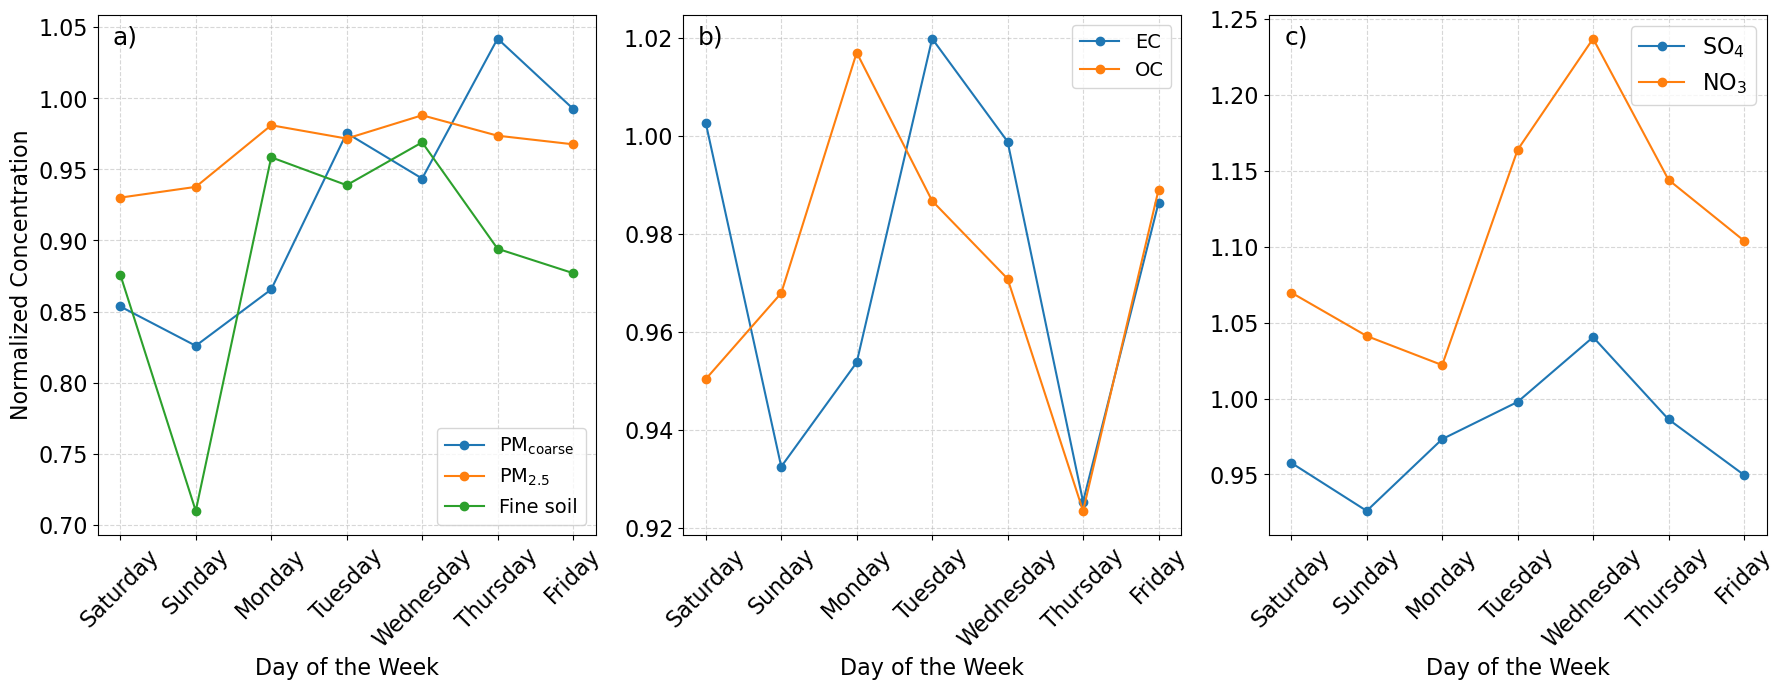

In [30]:
import matplotlib.pyplot as plt

# Variables per subplot
variables1 = {
    "CM_calculated_Val": r"$\mathrm{PM_{coarse}}$",
    "RCFM_Val": r"$\mathrm{PM_{2.5}}$",
    "SOILf_Val": "Fine soil",
}

variables2 = {
    "ECf_Val": "EC",
    "OCf_Val": "OC",
}

variables3 = {
    "SO4f_Val": r"$\mathrm{SO_4}$",
    "NO3f_Val": r"$\mathrm{NO_3}$",
    #"SeaSaltf_Val": "Sea Salt"
}

# Reorder to ensure consistent plotting
days_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
weekly_normalized_sorted = weekly_normalized.set_index("DayOfWeek").reindex(days_order)

# Plot
fig, axs = plt.subplots(1, 3, figsize=(18, 7), sharex=True)

# Subplot 1
for var, label in variables1.items():
    if var in weekly_normalized_sorted.columns:
        axs[0].plot(weekly_normalized_sorted.index, weekly_normalized_sorted[var], marker='o', label=label)

axs[0].set_title("", fontsize=16)
axs[0].set_ylabel("Normalized Concentration", fontsize=16)
axs[0].tick_params(axis='both', labelsize=16)
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend(fontsize=14, frameon=True, loc= 'lower right')
axs[0].text(0.08, 0.98, "a)", transform=axs[0].transAxes, fontsize=18, va='top', ha='right')

# Subplot 2
for var, label in variables2.items():
    if var in weekly_normalized_sorted.columns:
        axs[1].plot(weekly_normalized_sorted.index, weekly_normalized_sorted[var], marker='o', label=label)

axs[1].set_title("", fontsize=16)
axs[1].tick_params(axis='both', labelsize=16)
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend(fontsize=14, frameon=True)
axs[1].text(0.08, 0.98, "b)", transform=axs[1].transAxes, fontsize=18, va='top', ha='right')

# Subplot 3
for var, label in variables3.items():
    if var in weekly_normalized_sorted.columns:
        axs[2].plot(weekly_normalized_sorted.index, weekly_normalized_sorted[var], marker='o', label=label)

axs[2].set_title("", fontsize=16)
axs[2].tick_params(axis='both', labelsize=16)
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend(fontsize=16, frameon=True)
axs[2].text(0.08, 0.98, "c)", transform=axs[2].transAxes, fontsize=18, va='top', ha='right')

# Shared x-axis labels
for ax in axs:
    ax.set_xlabel("Day of the Week", fontsize=16)
    ax.set_xticks(range(len(days_order)))
    ax.set_xticklabels(days_order, rotation=45)

plt.tight_layout()
plt.show()


In [31]:
# List all the variable names you want to check
all_variables = list(variables1.keys()) + list(variables2.keys()) + list(variables3.keys())

# Dictionary to store weekly average for each variable
weekly_averages = {}

for var in all_variables:
    if var in weekly_normalized.columns:
        avg = weekly_normalized[var].mean()
        weekly_averages[var] = avg
        print(f"Weekly average for {var}: {avg:.3f} (equals 1? {np.isclose(avg, 1, atol=0.01)})")
    else:
        print(f"Variable {var} not found in weekly_normalized DataFrame.")



Weekly average for CM_calculated_Val: 0.928 (equals 1? False)
Weekly average for RCFM_Val: 0.964 (equals 1? False)
Weekly average for SOILf_Val: 0.889 (equals 1? False)
Weekly average for ECf_Val: 0.974 (equals 1? False)
Weekly average for OCf_Val: 0.972 (equals 1? False)
Weekly average for SO4f_Val: 0.976 (equals 1? False)
Weekly average for NO3f_Val: 1.112 (equals 1? False)


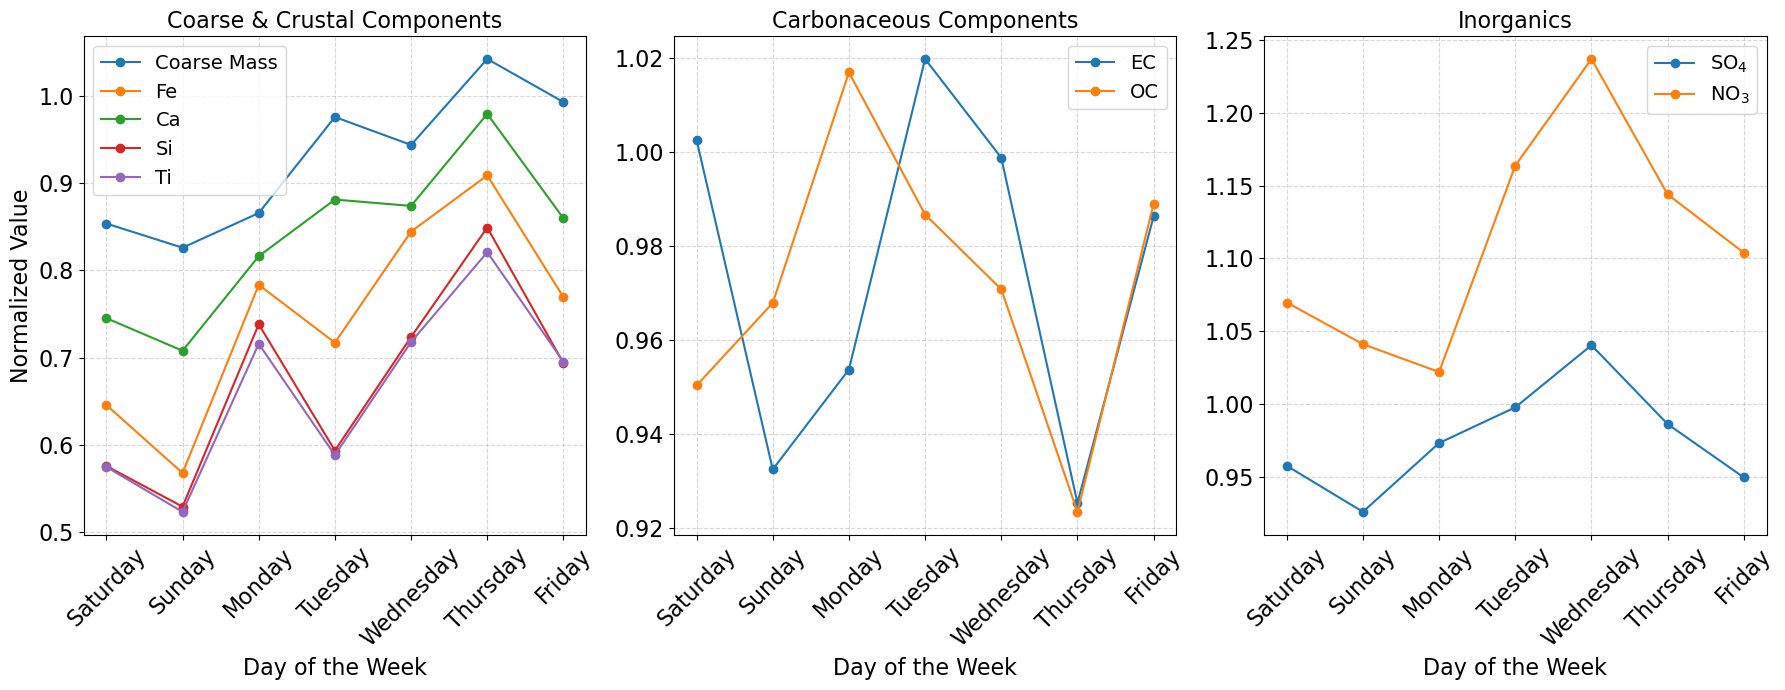

In [32]:
import matplotlib.pyplot as plt

# Variables per subplot
variables1 = {
    "CM_calculated_Val": "Coarse Mass",
    "FEf_Val": "Fe",
    "CAf_Val": "Ca",
    "SIf_Val": "Si",
    "TIf_Val": "Ti"
}

variables2 = {
    "ECf_Val": "EC",
    "OCf_Val": "OC"
}

variables3 = {
    "SO4f_Val": r"$SO_4$",
    "NO3f_Val": r"$NO_3$",
    #"SeaSaltf_Val": "Sea Salt"
}

# Reorder to ensure consistent plotting
days_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
weekly_normalized_sorted = weekly_normalized.set_index("DayOfWeek").reindex(days_order)

# Plot
fig, axs = plt.subplots(1, 3, figsize=(18, 7), sharex=True)

# Subplot 1
for var, label in variables1.items():
    if var in weekly_normalized_sorted.columns:
        axs[0].plot(weekly_normalized_sorted.index, weekly_normalized_sorted[var], marker='o', label=label)

axs[0].set_title("Coarse & Crustal Components", fontsize=16)
axs[0].set_ylabel("Normalized Value", fontsize=16)
axs[0].tick_params(axis='both', labelsize=16)
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend(fontsize=14, frameon=True)

# Subplot 2
for var, label in variables2.items():
    if var in weekly_normalized_sorted.columns:
        axs[1].plot(weekly_normalized_sorted.index, weekly_normalized_sorted[var], marker='o', label=label)

axs[1].set_title("Carbonaceous Components", fontsize=16)
axs[1].tick_params(axis='both', labelsize=16)
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend(fontsize=14, frameon=True)

# Subplot 3
for var, label in variables3.items():
    if var in weekly_normalized_sorted.columns:
        axs[2].plot(weekly_normalized_sorted.index, weekly_normalized_sorted[var], marker='o', label=label)

axs[2].set_title("Inorganics", fontsize=16)
axs[2].tick_params(axis='both', labelsize=16)
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend(fontsize=14, frameon=True)

# Shared x-axis labels
for ax in axs:
    ax.set_xlabel("Day of the Week", fontsize=16)
    ax.set_xticks(range(len(days_order)))
    ax.set_xticklabels(days_order, rotation=45)

plt.tight_layout()
plt.show()


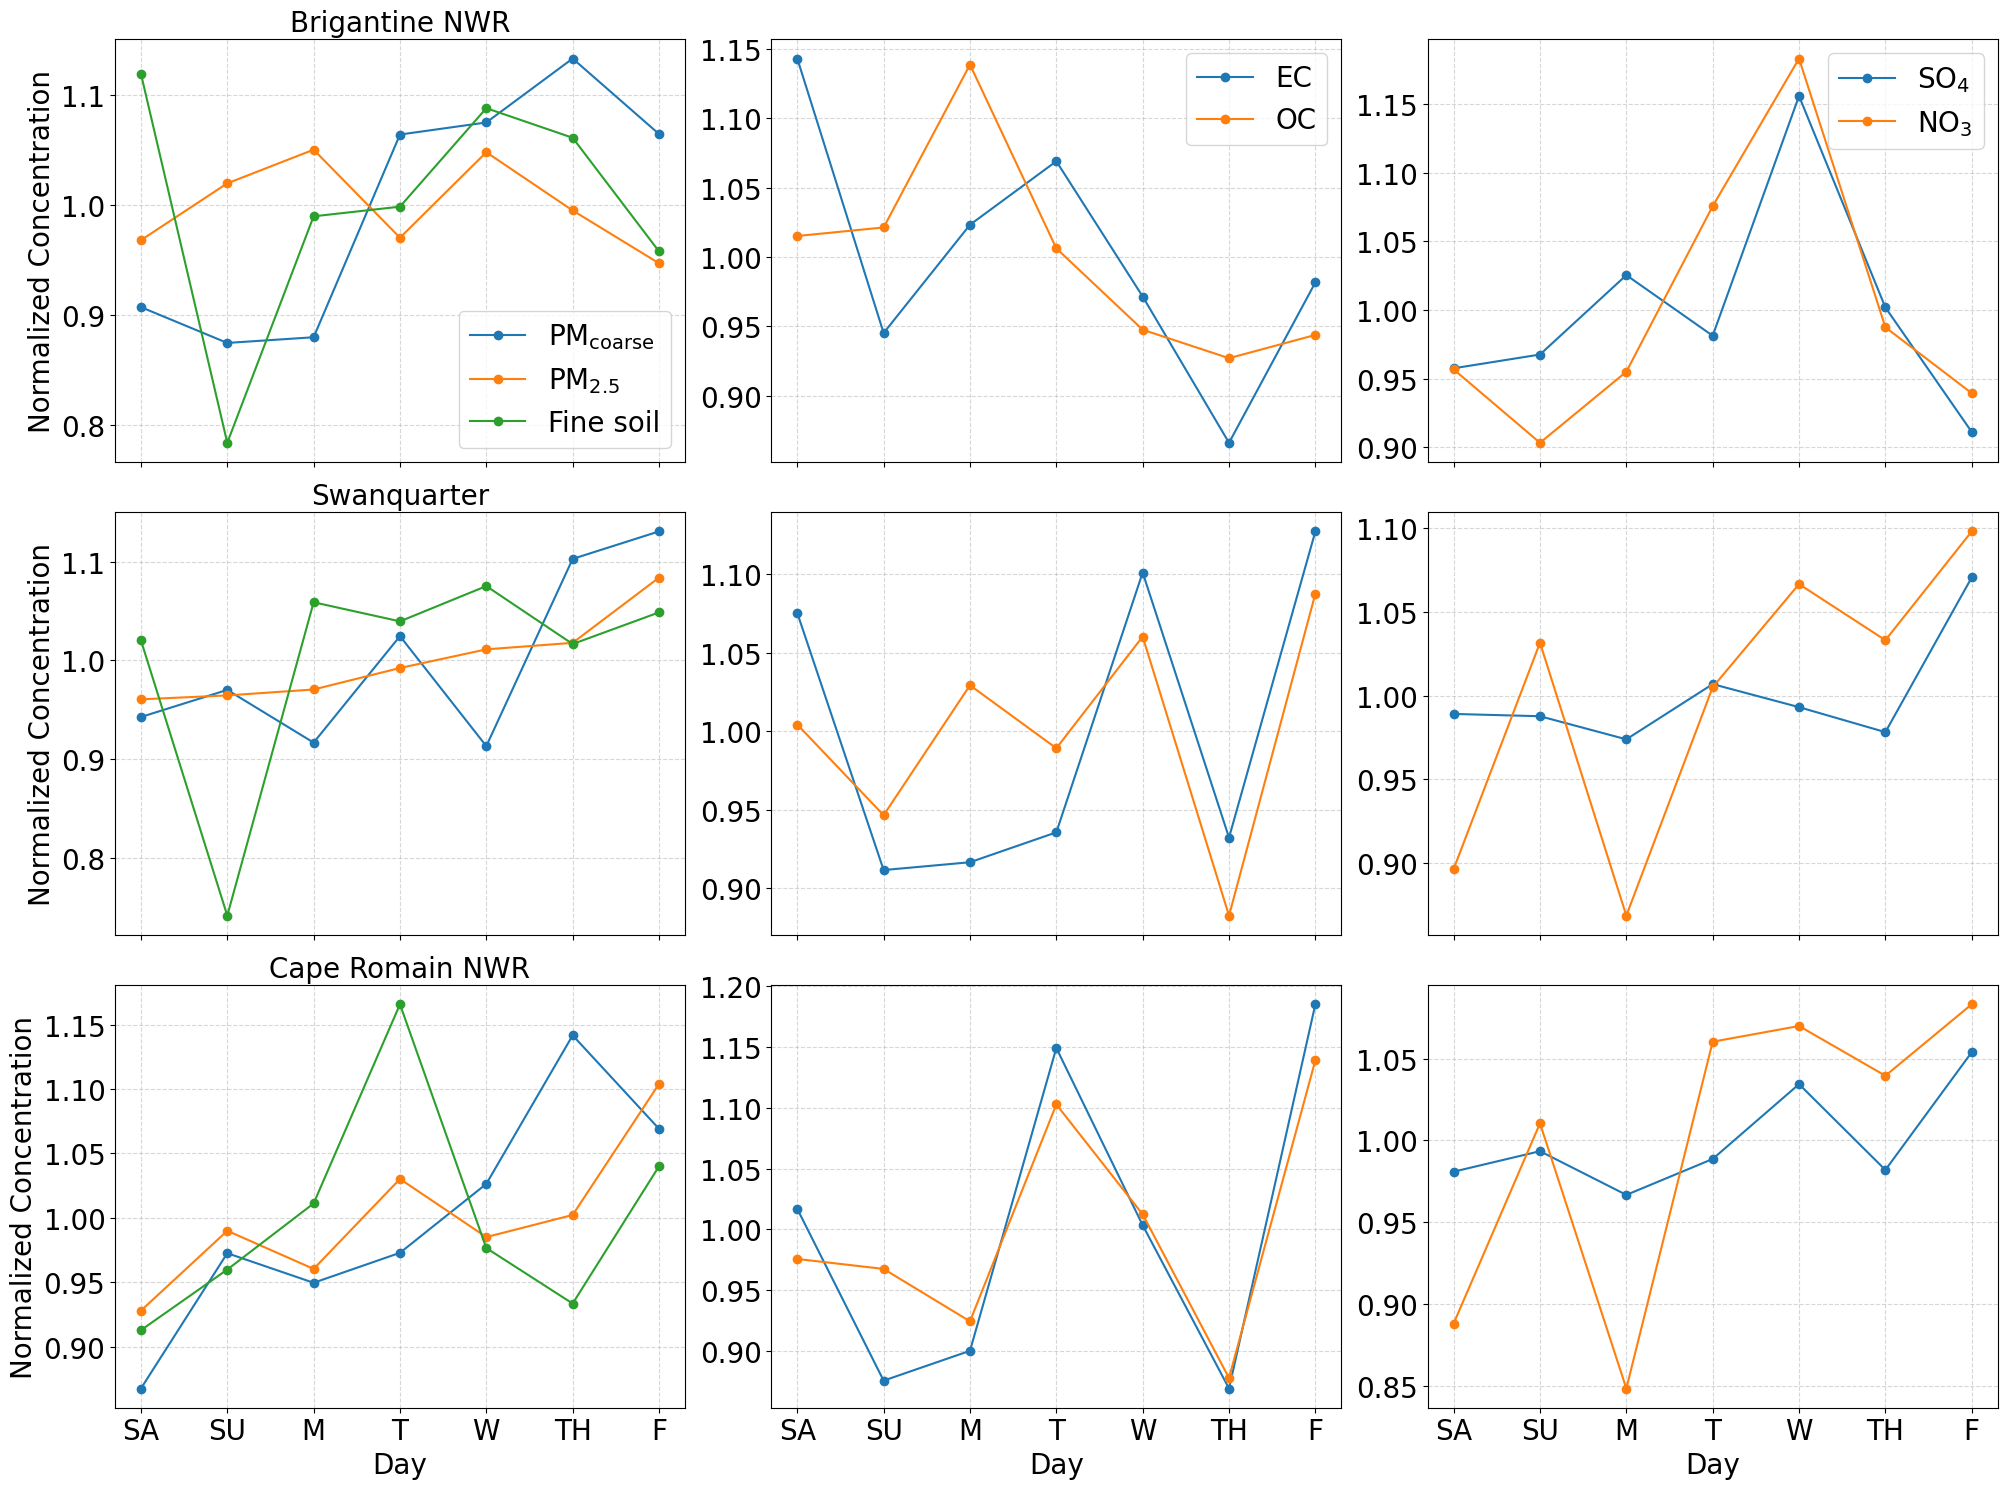

In [39]:
# path: plots/plot_three_sites_3x3.py
import pandas as pd
import matplotlib.pyplot as plt
from collections.abc import Mapping

# --- Config ---
variables1 = {
    "CM_calculated_Val": r"$\mathrm{PM_{coarse}}$",
    "RCFM_Val": r"$\mathrm{PM_{2.5}}$",
    "SOILf_Val": "Fine soil",
}
variables2 = {
    "ECf_Val": "EC",
    "OCf_Val": "OC",
}
variables3 = {
    "SO4f_Val": r"$\mathrm{SO_4}$",
    "NO3f_Val": r"$\mathrm{NO_3}$",
}
var_groups = [variables1, variables2, variables3]

# The three sites in row order (row1→row3)
target_sites = [
    "Brigantine NWR",
    "Swanquarter",
    "Cape Romain NWR",
]

# Saturday → Friday
days_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

# Short day labels (no rotation)
SHORT_DAY = {
    "Saturday": "SA", "Sunday": "SU", "Monday": "M",
    "Tuesday": "T", "Wednesday": "W", "Thursday": "TH", "Friday": "F"
}

def _to_df(obj) -> pd.DataFrame:
    """Coerce mapping-or-DataFrame input to a single DataFrame."""
    if isinstance(obj, pd.DataFrame):
        return obj.copy()
    if isinstance(obj, Mapping):
        frames = []
        for site, data in obj.items():
            if isinstance(data, pd.DataFrame):
                df_site = data.copy()
            elif isinstance(data, Mapping):
                keys = list(map(str, data.keys()))
                if set(keys).issubset(set(days_order)):
                    df_site = pd.DataFrame(data).T.reset_index().rename(columns={"index": "DayOfWeek"})
                else:
                    df_site = pd.DataFrame(data)
                    if df_site.index.astype(str).isin(days_order).all():
                        df_site = df_site.reset_index().rename(columns={"index": "DayOfWeek"})
                    elif set(df_site.columns.astype(str)).issubset(set(days_order)):
                        df_site = df_site.T.reset_index().rename(columns={"index": "DayOfWeek"})
                    else:
                        raise TypeError(f"Cannot infer day/variable orientation for site '{site}'.")
            else:
                raise TypeError(f"Unsupported type for site '{site}': {type(data)!r}")
            if "SiteName" not in df_site.columns:
                df_site = df_site.assign(SiteName=str(site))
            frames.append(df_site)
        if not frames:
            raise ValueError("Empty mapping for aggregated_normalized_data.")
        return pd.concat(frames, ignore_index=True, sort=False)
    raise TypeError("aggregated_normalized_data must be a DataFrame or a dict-like mapping.")

def _divide_by_site_mean(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Per-site, per-variable scaling: x_scaled = x / mean(site, var)."""
    out = df.copy()
    for v in cols:
        if v not in out.columns:
            continue
        mean_by_site = out.groupby("SiteName")[v].transform("mean")
        out[v] = out[v] / mean_by_site.replace(0, pd.NA)  # avoid divide-by-zero artifacts
    return out

# === Acquire user data ===
try:
    _raw = aggregated_normalized_data  # provided by your environment
except NameError as e:
    raise NameError("Define 'aggregated_normalized_data' before running this script.") from e

df = _to_df(_raw)

# Validate and clean
df = df.copy()
if not {"SiteName", "DayOfWeek"}.issubset(df.columns):
    raise KeyError("Data must include 'SiteName' and 'DayOfWeek' columns after coercion.")

all_vars = [v for g in var_groups for v in g.keys()]
present_vars = [v for v in all_vars if v in df.columns]
if not present_vars:
    raise KeyError("None of the expected variable columns were found.")

for v in present_vars:
    df[v] = pd.to_numeric(df[v], errors="coerce")

df["DayOfWeek"] = pd.Categorical(df["DayOfWeek"], categories=days_order, ordered=True)

# Per-site normalization: divide by site mean
df = _divide_by_site_mean(df, present_vars)

# --- Build 3×3 grid ---
fig, axes = plt.subplots(3, 3, figsize=(20, 15), sharex=True)

for row, site in enumerate(target_sites):
    sub = df[df["SiteName"] == site]
    if sub.empty:
        ax0 = axes[row, 0]
        ax0.text(0.5, 0.5, f"No data for\n{site}", ha="center", va="center", fontsize=20)
        ax0.set_axis_off()
        for col in range(1, 3):
            axes[row, col].set_axis_off()
        continue

    weekly = (
        sub.groupby("DayOfWeek", as_index=True)[present_vars]
           .mean()
           .reindex(days_order)
    )

    for col, var_map in enumerate(var_groups):
        ax = axes[row, col]
        for var, label in var_map.items():
            if var in weekly.columns:
                ax.plot(weekly.index, weekly[var], marker="o", label=label)
        if col == 0:
            ax.set_title(site, fontsize=20)
            ax.set_ylabel("Normalized Concentration", fontsize=20)
        else:
            ax.set_title("")
        if row == 0:
            ax.legend(fontsize=20, frameon=True, loc="best")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.tick_params(axis="both", labelsize=20)

# X labels on bottom row only — short labels, no rotation
short_labels = [SHORT_DAY[d] for d in days_order]
for ax in axes[2, :]:
    ax.set_xlabel("Day", fontsize=20)
    ax.set_xticks(range(len(days_order)))
    ax.set_xticklabels(short_labels)  # no rotation

plt.tight_layout()
plt.show()


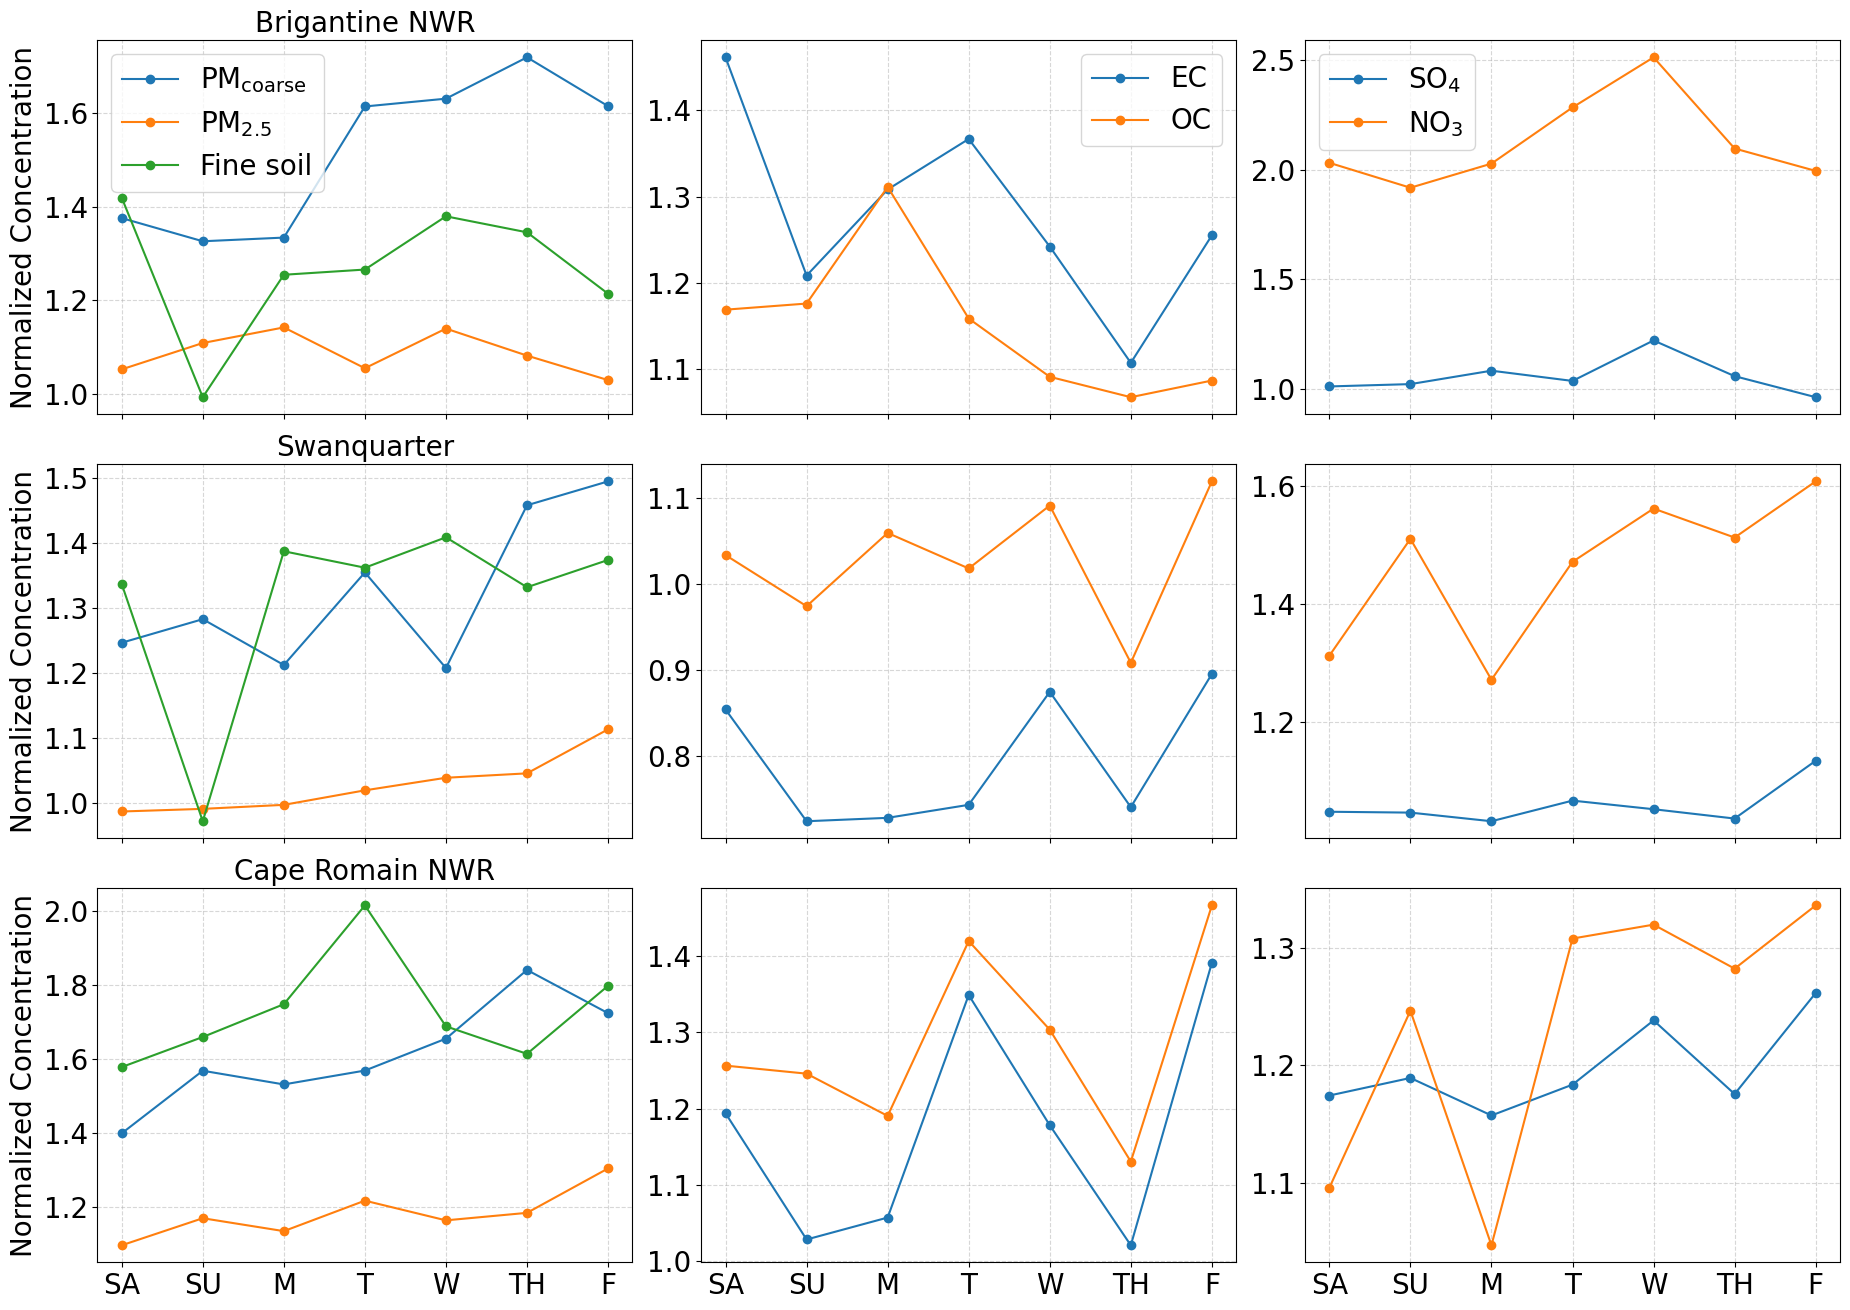

In [34]:
# path: plots/plot_three_sites_3x3.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections.abc import Mapping

SHORT_DAY = {
    "Saturday": "SA", "Sunday": "SU", "Monday": "M",
    "Tuesday": "T", "Wednesday": "W", "Thursday": "TH", "Friday": "F"
}

# --- Config ---
variables1 = {
    "CM_calculated_Val": r"$\mathrm{PM_{coarse}}$",
    "RCFM_Val": r"$\mathrm{PM_{2.5}}$",
    "SOILf_Val": "Fine soil",
}
variables2 = {
    "ECf_Val": "EC",
    "OCf_Val": "OC",
}
variables3 = {
    "SO4f_Val": r"$\mathrm{SO_4}$",
    "NO3f_Val": r"$\mathrm{NO_3}$",
}
var_groups = [variables1, variables2, variables3]

# The three sites in row order (row1→row3)
target_sites = [
    "Brigantine NWR",
    "Swanquarter",
    "Cape Romain NWR",
]

# Saturday → Friday
days_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
x = np.arange(len(days_order))                                  # canonical numeric axis
short_ticks = [SHORT_DAY[d] for d in days_order]

# --- Helper: coerce aggregated_normalized_data into a single DataFrame ---
def _to_df(obj) -> pd.DataFrame:
    if isinstance(obj, pd.DataFrame):
        return obj.copy()
    if isinstance(obj, Mapping):
        frames = []
        for site, data in obj.items():
            if isinstance(data, pd.DataFrame):
                df_site = data.copy()
            elif isinstance(data, Mapping):
                keys = list(map(str, data.keys()))
                if set(keys).issubset(set(days_order)):
                    df_site = pd.DataFrame(data).T.reset_index().rename(columns={"index": "DayOfWeek"})
                else:
                    df_site = pd.DataFrame(data)
                    if df_site.index.astype(str).isin(days_order).all():
                        df_site = df_site.reset_index().rename(columns={"index": "DayOfWeek"})
                    elif set(df_site.columns.astype(str)).issubset(set(days_order)):
                        df_site = df_site.T.reset_index().rename(columns={"index": "DayOfWeek"})
                    else:
                        raise TypeError(f"Cannot infer day/variable orientation for site '{site}'.")
            else:
                raise TypeError(f"Unsupported type for site '{site}': {type(data)!r}")
            if "SiteName" not in df_site.columns:
                df_site = df_site.assign(SiteName=str(site))
            frames.append(df_site)
        if not frames:
            raise ValueError("Empty mapping for aggregated_normalized_data.")
        return pd.concat(frames, ignore_index=True, sort=False)
    raise TypeError("aggregated_normalized_data must be a DataFrame or a dict-like mapping.")

# === Acquire user data ===
try:
    _raw = aggregated_normalized_data  # provided by your environment
except NameError as e:
    raise NameError("Define 'aggregated_normalized_data' before running this script.") from e

df = _to_df(_raw)

# Validate and clean
df = df.copy()
if not {"SiteName", "DayOfWeek"}.issubset(df.columns):
    raise KeyError("Data must include 'SiteName' and 'DayOfWeek' columns after coercion.")

all_vars = [v for g in var_groups for v in g.keys()]
present_vars = [v for v in all_vars if v in df.columns]
if not present_vars:
    raise KeyError("None of the expected variable columns were found.")

for v in present_vars:
    df[v] = pd.to_numeric(df[v], errors="coerce")

df["DayOfWeek"] = pd.Categorical(df["DayOfWeek"], categories=days_order, ordered=True)

# --- Build 3×3 grid ---
fig, axes = plt.subplots(3, 3, figsize=(20, 15), sharex=True)

for row, site in enumerate(target_sites):
    sub = df[df["SiteName"] == site]
    if sub.empty:
        ax0 = axes[row, 0]
        ax0.text(0.5, 0.5, f"No data for\n{site}", ha="center", va="center", fontsize=17)
        ax0.set_axis_off()
        for col in range(1, 3):
            axes[row, col].set_axis_off()
        continue

    weekly = (
        sub.groupby("DayOfWeek", as_index=True)[present_vars]
           .mean()
           .reindex(days_order)
    )

    for col, var_map in enumerate(var_groups):
        ax = axes[row, col]
        for var, label in var_map.items():
            if var in weekly.columns:
                # Build y in canonical weekday order; plot against numeric x.
                y = [weekly.loc[d, var] for d in days_order]
                ax.plot(x, y, marker="o", label=label)
        if col == 0:
            ax.set_title(site, fontsize=20)
            ax.set_ylabel("Normalized Concentration", fontsize=20)
        else:
            ax.set_title("")
        if row == 0:
            ax.legend(fontsize=20, frameon=True, loc="best")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.tick_params(axis="both", labelsize=20)

# X ticks/labels only on bottom row, using short labels
for ax in axes[2, :]:
    ax.set_xlabel("", fontsize=20)
    ax.set_xticks(x)
    ax.set_xticklabels(short_ticks, rotation=0)  # ← shortened tick labels

# Hide x tick labels on rows 0–1 (keeps shared x but avoids clutter)
for ax in axes[0, :].tolist() + axes[1, :].tolist():
    ax.tick_params(labelbottom=False)

fig.tight_layout(rect=[0.06, 0.06, 0.99, 0.94])
plt.show()


In [ ]:
# Define variables to plot with custom labels
variables_to_plot = {
    "CM_calculated_Val": "Coarse Mass",
    "FEf_Val": "Fe",
    "CAf_Val": "Ca",
    "SIf_Val": "Si",
    "TIf_Val": "Ti"
}

# Define target sites for plotting
target_sites = [
    "Brigantine NWR", 
    "Dolly Sods Wilderness", 
    "James River Face Wilderness", 
    "Shenandoah NP",
    "Swanquarter",
    "Cape Romain NWR",
]

# Define day order for correct plotting
days_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

# Create a 2x2 subplot
fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharex=True, sharey=False)
axes = axes.flatten()  # Convert to a 1D list for easy iteration

# Iterate over sites and create subplots
for i, site in enumerate(target_sites):
    ax = axes[i]

    # Extract data for the current site
    site_data = aggregated_normalized_data.get(site, {})

    if not site_data:
        ax.set_title(f"{site} (No Data)")
        continue  # Skip if no data available

    # Convert dictionary to DataFrame for plotting
    df = pd.DataFrame(site_data).T  # Convert to DataFrame (DayOfWeek → Variables)
    df = df.reindex(days_order)  # Ensure correct day order

    # Plot each variable
    for var, label in variables_to_plot.items():
        if var in df.columns:
            ax.plot(df.index, df[var], marker="o", label=label)

    # Formatting
    ax.set_title(site, fontsize=16)
    ax.tick_params(axis='both', labelsize=16)
    
    # X-axis: Show labels only on the last row
    if i in [3, 4, 5]:  
        ax.set_xticks(range(len(days_order)))
        ax.set_xticklabels(days_order, rotation=45, fontsize=16)
        ax.set_xlabel("Day of the Week", fontsize=16)
    else:
        ax.set_xticklabels([])

    # Y-axis: Show labels only on the first column
    if i % 2 == 0:  
        ax.set_ylabel("Normalized Concentration", fontsize=16)

    # Add grid for better readability
    ax.grid(True, linestyle="--", alpha=0.7)

    # Add legend only in the first subplot
    #if i == 0:
   #     ax.legend(fontsize=12, loc="upper left", frameon=True)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=5, fontsize=16, frameon=True)

# Adjust layout and spacing
plt.subplots_adjust(hspace=0.2, wspace=0.2)
plt.show()


In [ ]:
# path: plots/plot_three_sites_3x3.py
import pandas as pd
import matplotlib.pyplot as plt
import string
from collections.abc import Mapping

# --- Config ---
variables1 = {
    "CM_calculated_Val": r"$\mathrm{PM_{coarse}}$",
    "RCFM_Val": r"$\mathrm{PM_{2.5}}$",
    "SOILf_Val": "Fine soil",
}
variables2 = {
    "ECf_Val": "EC",
    "OCf_Val": "OC",
}
variables3 = {
    "SO4f_Val": r"$\mathrm{SO_4}$",
    "NO3f_Val": r"$\mathrm{NO_3}$",
}
var_groups = [variables1, variables2, variables3]

# The three sites in row order (row1→row3)
target_sites = [
    "Brigantine NWR",
    "Swanquarter",
    "Cape Romain NWR",
]

# Saturday → Friday
days_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

# --- Helper: coerce aggregated_normalized_data into a single DataFrame ---
# Accepts either a DataFrame with columns ['SiteName','DayOfWeek', ...vars]
# or a dict: {SiteName: DataFrame/dict-like}
def _to_df(obj) -> pd.DataFrame:
    if isinstance(obj, pd.DataFrame):
        return obj.copy()
    if isinstance(obj, Mapping):
        frames = []
        for site, data in obj.items():
            if isinstance(data, pd.DataFrame):
                df_site = data.copy()
            elif isinstance(data, Mapping):
                keys = list(map(str, data.keys()))
                if set(keys).issubset(set(days_order)):
                    df_site = pd.DataFrame(data).T.reset_index().rename(columns={"index": "DayOfWeek"})
                else:
                    df_site = pd.DataFrame(data)
                    if df_site.index.astype(str).isin(days_order).all():
                        df_site = df_site.reset_index().rename(columns={"index": "DayOfWeek"})
                    elif set(df_site.columns.astype(str)).issubset(set(days_order)):
                        df_site = df_site.T.reset_index().rename(columns={"index": "DayOfWeek"})
                    else:
                        raise TypeError(f"Cannot infer day/variable orientation for site '{site}'.")
            else:
                raise TypeError(f"Unsupported type for site '{site}': {type(data)!r}")
            if "SiteName" not in df_site.columns:
                df_site = df_site.assign(SiteName=str(site))
            frames.append(df_site)
        if not frames:
            raise ValueError("Empty mapping for aggregated_normalized_data.")
        return pd.concat(frames, ignore_index=True, sort=False)
    raise TypeError("aggregated_normalized_data must be a DataFrame or a dict-like mapping.")

# === Acquire user data ===
try:
    _raw = aggregated_normalized_data  # provided by your environment
except NameError as e:
    raise NameError("Define 'aggregated_normalized_data' before running this script.") from e

df = _to_df(_raw)

# Validate and clean
df = df.copy()
if not {"SiteName", "DayOfWeek"}.issubset(df.columns):
    raise KeyError("Data must include 'SiteName' and 'DayOfWeek' columns after coercion.")

all_vars = [v for g in var_groups for v in g.keys()]
present_vars = [v for v in all_vars if v in df.columns]
if not present_vars:
    raise KeyError("None of the expected variable columns were found.")

for v in present_vars:
    df[v] = pd.to_numeric(df[v], errors="coerce")

df["DayOfWeek"] = pd.Categorical(df["DayOfWeek"], categories=days_order, ordered=True)

# --- Build 3×3 grid ---
fig, axes = plt.subplots(3, 3, figsize=(20, 15), sharex=True)

# panel labels a) .. i)
panel_labels = [f"{ch})" for ch in string.ascii_lowercase[:9]]

for row, site in enumerate(target_sites):
    sub = df[df["SiteName"] == site]
    if sub.empty:
        ax0 = axes[row, 0]
        ax0.text(0.5, 0.5, f"No data for\n{site}", ha="center", va="center", fontsize=14)
        ax0.set_axis_off()
        for col in range(1, 3):
            axes[row, col].set_axis_off()
        continue

    weekly = (
        sub.groupby("DayOfWeek", as_index=True)[present_vars]
           .mean()
           .reindex(days_order)
    )

    for col, var_map in enumerate(var_groups):
        ax = axes[row, col]
        for var, label in var_map.items():
            if var in weekly.columns:
                ax.plot(weekly.index, weekly[var], marker="o", label=label)

        # Site names only in first column
        if col == 0:
            ax.set_title(site, fontsize=16)
            ax.set_ylabel("Normalized Concentration", fontsize=16)
        else:
            ax.set_title("")

        # Legends only in the first row
        if row == 0:
            ax.legend(fontsize=14, frameon=True, loc="best")

        ax.grid(True, linestyle="--", alpha=0.5)
        ax.tick_params(axis="both", labelsize=16)

        # Panel label (a), b), ...) at top-left inside each subplot
        label = panel_labels[row * 3 + col]
        ax.text(0.5, 0.98, label, transform=ax.transAxes, ha="left", va="top", fontsize=18)
      
for ax in axes[2, :]:
    ax.set_xlabel("Day of the Week", fontsize=16)
    ax.set_xticks(range(len(days_order)))
    ax.set_xticklabels(days_order, rotation=45)
    
plt.tight_layout()
plt.show()


In [ ]:
# Define variables to plot with custom labels
variables_to_plot = {
    "SO4f_Val": r"$\mathrm{SO_4}$",
    "NO3f_Val": r"$\mathrm{NO_3}$",
    #"Pb_Zn_Ratio": "Pb/(Pb+Zn)"
}

# Define target sites for plotting

# Define day order for correct plotting
days_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

# Create a 2x2 subplot
fig, axes = plt.subplots(2, 3, figsize=(22, 12), sharex=True, sharey=False)
axes = axes.flatten()  # Convert to a 1D list for easy iteration

# Iterate over sites and create subplots
for i, site in enumerate(target_sites):
    ax = axes[i]

    # Extract data for the current site
    site_data = aggregated_normalized_data.get(site, {})

    if not site_data:
        ax.set_title(f"{site} (No Data)")
        continue  # Skip if no data available

    # Convert dictionary to DataFrame for plotting
    df = pd.DataFrame(site_data).T  # Convert to DataFrame (DayOfWeek → Variables)
    df = df.reindex(days_order)  # Ensure correct day order

    # Plot each variable
    for var, label in variables_to_plot.items():
        if var in df.columns:
            ax.plot(df.index, df[var], marker="o", label=label)

    # Formatting
    ax.set_title(site, fontsize=16)
    ax.tick_params(axis='both', labelsize=16)
    
    # X-axis: Show labels only on the last row
    if i in [3, 4, 5]:  
        ax.set_xticks(range(len(days_order)))
        ax.set_xticklabels(days_order, rotation=45, fontsize=16)
        ax.set_xlabel("Day of the Week", fontsize=16)
    else:
        ax.set_xticklabels([])

    # Y-axis: Show labels only on the first column
    if i % 2 == 0:  
        ax.set_ylabel("Normalized Concentration", fontsize=16)

    # Add grid for better readability
    ax.grid(True, linestyle="--", alpha=0.7)

    # Add legend only in the first subplot
    #if i == 0:
        #ax.legend(fontsize=12, loc="upper left", frameon=True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.78, 1.0), fontsize=16, frameon=True)

# Adjust layout and spacing
plt.subplots_adjust(hspace=0.2, wspace=0.2)
plt.show()


In [ ]:
def simple_read(path):
    try:
        # Step 1: Locate the R0 line, then read the next line as header
        header_line = None
        with open(path, 'r') as f:
            for i, line in enumerate(f):
                if line.startswith("R0: File generated from data submitted"):
                    header_line = i + 1  # header is on the next line
                    break

        if header_line is None:
            raise ValueError("❌ Could not find R0 header marker in file.")

        # Step 2: Read data using header line
        data = pd.read_csv(path, skiprows=header_line, sep=",", on_bad_lines="skip")
        data.columns = [col.strip() for col in data.columns]

        # Step 3: Extract base date from filename
        match = re.search(r'(\d{4})(\d{2})(\d{2})', path)
        if not match:
            raise ValueError("❌ Date not found in path.")
        year, month, day = map(int, match.groups())
        base_date = datetime(year, month, day)

        # Step 4: Parse time columns
        for col in data.columns:
            if "Time" in col:
                data[col] = pd.to_numeric(data[col], errors="coerce")
                data[col] = pd.to_timedelta(data[col], unit="s") + base_date

        # Step 5: Clean missing values
        data = data.replace([-999999, -66666, -888888], pd.NA)

        return data

    except Exception as e:
        print(f"⚠️ Error reading {path}:\n{e}")
        return None



def process_multiple_files(file_paths):
    all_data = []
    for path in file_paths:
        df = simple_read(path)
        if df is not None:
            all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

In [ ]:
file_dir = 'C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/2020'
file_paths = glob.glob(file_dir + '/**/*.ict', recursive=True)

D2020 = process_multiple_files(file_paths)

D2020

In [ ]:
# List of dates to remove
"""dates_to_remove = [
    "2020-08-17", "2020-08-21", "2020-09-02", "2020-09-10", "2020-09-11", "2020-09-29",
    "2021-03-23", "2021-05-15", "2021-05-18", "2021-05-21", "2021-06-02", "2021-06-07",
    "2021-06-08", "2021-06-26", "2021-06-28", "2021-06-29", "2021-06-30", "2022-02-02",
    "2022-02-03", "2022-03-07", "2022-05-10", "2022-05-16", "2022-06-07", "2022-06-08"
]

# Convert Time_Start column to datetime format
D2020['Time_Start'] = pd.to_datetime(D2020['Time_Start'])

# Filter out the rows with the specified dates
D2021 = D2020[~D2020['Time_Start'].dt.strftime('%Y-%m-%d').isin(dates_to_remove)]"""
D2021 = D2020.copy()
print("Filtered DataFrame:")
print(D2021)


In [ ]:
"""D2021["LegIndex_CORRAL"] = D2021["LegIndex_CORRAL"].apply(lambda x: str(x)[-2:] if pd.notna(x) else pd.NA)
D2021["LegIndex_CORRAL"]"""


In [ ]:
# Step 1: Create a helper function to find valid rows for each date
def get_valid_indices_by_leg(df):
    valid_indices = []
    for day, group in df.groupby(df["Time_Start"].dt.date):
        group_sorted = group.sort_values("Time_Start")
        drop_until = 0
        for i, val in enumerate(group_sorted["LegIndex_CORRAL"]):
            if val in {"00", "01", "08"}:
                drop_until = i + 1
            else:
                break
        valid_indices.extend(group_sorted.index[drop_until:])
    return valid_indices

valid_indices = get_valid_indices_by_leg(D2021)
D2020_filtered = D2021.loc[valid_indices].copy()


In [ ]:
D2020_filtered = D2020_filtered[D2020_filtered["GPS_Altitude_THORNHILL"] < 2000].copy()
D2020_filtered["CO_ppm_DISKIN"] *= 1000


for col in D2020_filtered.columns:
    if D2020_filtered[col].dtype == "object":
        D2020_filtered[col] = pd.to_numeric(D2020_filtered[col], errors="coerce")
D2020_filtered = D2020_filtered.replace(-8888, np.NaN)#np.NaN)
D2020_filtered = D2020_filtered.replace(-9999, np.NaN)#np.NaN)
D2020_filtered

In [ ]:
#D2020_filtered = D2020_filtered[D2020_filtered["Org_Ave_IsoK_STP_ZIEMBA"] < 10].copy()

D2020_filtered = D2020_filtered[
    (D2020_filtered["Org_Ave_IsoK_STP_ZIEMBA"] < 10) &
    (D2020_filtered["CO_ppm_DISKIN"] < 200)
].copy()

D2020_filtered

In [ ]:
D2020_filtered['Vapor_Pressure'] = (D2020_filtered['H2O_DLH_DISKIN'] * D2020_filtered['Static_Pressure_THORNHILL']) / 1e6
# Display the updated DataFrame
D2020_filtered['Vapor_Pressure']
D2020_filtered['dry_air_Pressure'] = D2020_filtered['Static_Pressure_THORNHILL'] - D2020_filtered['Vapor_Pressure']
D2020_filtered['dry_air_Pressure']

D2020_filtered['Static_Air_Temp_THORNHILL'] = D2020_filtered['Static_Air_Temp_THORNHILL'] + 273.15  # Convert to Kelvin

# Constants
R_d = 287.05  # Specific gas constant for dry air (J/(kg⋅K))
R_v = 461.5   # Specific gas constant for water vapor (J/(kg⋅K))

# Compute total (moist) air density
D2020_filtered['Moist_Air_Density'] = (((D2020_filtered['Static_Pressure_THORNHILL'] * 100) - (D2020_filtered['Vapor_Pressure']*100)) / (R_d * D2020_filtered['Static_Air_Temp_THORNHILL'])) + \
                             ((D2020_filtered['Vapor_Pressure'] * 100) / (R_v * D2020_filtered['Static_Air_Temp_THORNHILL']))

#D2020['Mass_concgt1um'] = D2020['IntegV_gt1000nm_LAS_ZIEMBA'] * D2020['Moist_Air_Density'] * 1e-3
#D2020['Mass_conc100to1000nm'] = D2020['IntegV_100to1000nm_LAS_ZIEMBA'] * D2020['Moist_Air_Density'] * 1e-3
#D2020['Mass_concLAS'] = D2020['vLAS_AmmSO4_ZIEMBA'] * D2020['Moist_Air_Density'] * 1e-3
#D2020['Mass_conCSMPS'] = D2020['vSMPS_ZIEMBA'] * D2020['Moist_Air_Density'] * 1e-3
#D2020["ratio"] = (D2020["CNgt3nm_ZIEMBA"] / D2020["CNgt10nm_ZIEMBA"]).astype("float64")
# Compute ratio only where both values are valid and denominator ≠ 0
valid_mask = (
    D2020_filtered["CNgt3nm_ZIEMBA"].notna() &
    D2020_filtered["CNgt10nm_ZIEMBA"].notna() &
    (D2020_filtered["CNgt10nm_ZIEMBA"] != 0)
)

# Assign ratio where valid, leave others as NaN
D2020_filtered["ratio"] = np.nan  # Ensure column exists
D2020_filtered.loc[valid_mask, "ratio"] = (
    D2020_filtered.loc[valid_mask, "CNgt3nm_ZIEMBA"] /
    D2020_filtered.loc[valid_mask, "CNgt10nm_ZIEMBA"]
).astype("float64")

D2020_filtered["Subtract_3_10"] = (D2020_filtered["CNgt3nm_ZIEMBA"] - D2020_filtered["CNgt10nm_ZIEMBA"])
D2020_filtered["Subtract_10_0.1"] = (D2020_filtered["CNgt3nm_ZIEMBA"] - D2020_filtered["nSMPS_ZIEMBA"])
D2020_filtered["TSA"] = (D2020_filtered["sSMPS_ZIEMBA"] + D2020_filtered["IntegS_100to1000nm_LAS_ZIEMBA"] + D2020_filtered["IntegS_gt1000nm_LAS_ZIEMBA"])


# Display the updated DataFrame
D2020_filtered



In [ ]:
# Define the latitude and longitude range
latitude_start = 37.095692
longitude_start = -76.322753
latitude_end = 36.938 #36.88
longitude_end = -72.666

# Filter the data based on the latitude and longitude range
Zibut = D2020_filtered[
    (D2020_filtered['Latitude_THORNHILL'] <= latitude_start) &
    (D2020_filtered['Latitude_THORNHILL'] >= latitude_end) &
    (D2020_filtered['Longitude_THORNHILL'] >= longitude_start) &
    (D2020_filtered['Longitude_THORNHILL'] <= longitude_end)
]

# Display the filtered data
Zibut

In [ ]:
# Define the main latitude and longitude range for Oxana
latitude_start = 37.095692
longitude_start = -76.322753
latitude_end = 34.363
longitude_end = -73.759

# Filter Oxana to include only the main diagonal flight path
Oxana = D2020_filtered[
    (D2020_filtered['Latitude_THORNHILL'] <= latitude_start) &
    (D2020_filtered['Latitude_THORNHILL'] >= latitude_end) &
    (D2020_filtered['Longitude_THORNHILL'] >= longitude_start) &
    (D2020_filtered['Longitude_THORNHILL'] <= longitude_end)
]

# Define specific exclusion zones (red regions)
# Zone 1: Upper horizontal region
zone_1 = (
    (Oxana['Latitude_THORNHILL'] > 36.5) &
    (Oxana['Latitude_THORNHILL'] < 37.2) &
    (Oxana['Longitude_THORNHILL'] > -75.5) &
    (Oxana['Longitude_THORNHILL'] < -74.0)
)

# Zone 2: Middle curve region
zone_2 = (
    (Oxana['Latitude_THORNHILL'] > 36.0) &
    (Oxana['Latitude_THORNHILL'] < 36.5) &
    (Oxana['Longitude_THORNHILL'] > -75.0) &
    (Oxana['Longitude_THORNHILL'] < -74.2)
)

# Zone 3: Top-left region (corrected)
zone_3 = (
    (Oxana['Latitude_THORNHILL'] > 36.9) &  # Refined latitude range
    (Oxana['Latitude_THORNHILL'] < 37.15) &
    (Oxana['Longitude_THORNHILL'] > -76.5) &  # Narrower longitude range
    (Oxana['Longitude_THORNHILL'] < -75.0)
)

zone_4 = (
    (Oxana['Latitude_THORNHILL'] > 36.0) &  # Refined latitude range
    (Oxana['Latitude_THORNHILL'] < 37.2) &
    (Oxana['Longitude_THORNHILL'] > -74.5) &  # Narrower longitude range
    (Oxana['Longitude_THORNHILL'] < -73.0)
)

zone_5 = (
    (Oxana['Latitude_THORNHILL'] > 36.1) &  # Refined latitude range
    (Oxana['Latitude_THORNHILL'] < 36.9) &
    (Oxana['Longitude_THORNHILL'] > -75.8) &  # Narrower longitude range
    (Oxana['Longitude_THORNHILL'] < -75.5)
)

zone_6 = (
    (Oxana['Latitude_THORNHILL'] > 34.0) &  # Refined latitude range
    (Oxana['Latitude_THORNHILL'] < 34.8) &
    (Oxana['Longitude_THORNHILL'] > -75) &  # Narrower longitude range
    (Oxana['Longitude_THORNHILL'] < -74.5)
)

zone_7 = (
    (Oxana['Latitude_THORNHILL'] > 35) &
    (Oxana['Latitude_THORNHILL'] < 35.8) &
    (Oxana['Longitude_THORNHILL'] > -74.05) &
    (Oxana['Longitude_THORNHILL'] < -73.5)
)

zone_8 = (
    (Oxana['Latitude_THORNHILL'] > 35.4) &
    (Oxana['Latitude_THORNHILL'] < 36.5) &
    (Oxana['Longitude_THORNHILL'] > -75) &
    (Oxana['Longitude_THORNHILL'] < -74.7)
)


zone_9 = (
    (Oxana['Latitude_THORNHILL'] > 36) &
    (Oxana['Latitude_THORNHILL'] < 36.5) &
    (Oxana['Longitude_THORNHILL'] > -75.1) &
    (Oxana['Longitude_THORNHILL'] < -75)
)


zone_10 = (
    (Oxana['Latitude_THORNHILL'] > 36.3) &
    (Oxana['Latitude_THORNHILL'] < 37) &
    (Oxana['Longitude_THORNHILL'] > -76) &
    (Oxana['Longitude_THORNHILL'] < -75.7)
)

# Combine exclusion zones
red_region = zone_1 | zone_2 | zone_3 | zone_4 | zone_5 | zone_6 | zone_7 | zone_8 | zone_9 | zone_10

# Exclude points in the red regions
Oxana_filtered = Oxana[~red_region].copy()
Oxana_filtered


In [ ]:
# List of dates to remove
dates_to_remove = [
    "2020-03-11", "2020-08-20", "2021-05-19", "2021-06-05", "2021-06-24", "2022-02-22", "2022-05-05", "2022-05-21"
]

# Convert Time_Start column to datetime format
Oxana_filtered['Time_Start'] = pd.to_datetime(Oxana_filtered['Time_Start'])

# Filter out the rows with the specified dates
Oxana_filtered = Oxana_filtered[~Oxana_filtered['Time_Start'].dt.strftime('%Y-%m-%d').isin(dates_to_remove)]

print("Filtered DataFrame:")
print(Oxana_filtered)

In [ ]:
combined_reference_df = pd.concat([Oxana_filtered, Zibut])
combined_reference_df

In [ ]:
# Add weekday name
'''combined_reference_df['Weekday'] = combined_reference_df['Time_Start'].dt.day_name()

# Group by weekday and compute median for each column
weekday_medians = combined_reference_df.groupby('Weekday').median(numeric_only=True)

# Optional: Order weekdays
weekday_order = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekday_medians = weekday_medians.reindex(weekday_order)

weekday_medians

weekday_medians.to_excel("C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/Combined_Weekday_Medians_withfilter.xlsx")'''


In [ ]:
# Define weekday order
weekdays_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Create subplots (2 rows × 4 columns for space; we'll leave one blank)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, day in enumerate(weekdays_order):
    subset = combined_reference_df[combined_reference_df["Weekday"] == day]
    data = subset["Org_Ave_IsoK_STP_ZIEMBA"].dropna()

    axes[i].hist(data, bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(day, fontsize=16)
    axes[i].set_xlabel("Organics", fontsize=16)
    axes[i].set_ylabel("Frequency", fontsize = 16)
    axes[i].tick_params(axis='both', labelsize=16)

# Turn off unused last plot (8th subplot)
axes[-1].axis("off")

plt.suptitle("Organics Distribution by Day of Week (Filtered Oxana/Zibut Data)", fontsize=18)


plt.tight_layout()
plt.show()


In [ ]:
# Define weekday order
weekdays_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Create subplots (2 rows × 4 columns for space; we'll leave one blank)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, day in enumerate(weekdays_order):
    subset = combined_reference_df[combined_reference_df["Weekday"] == day]
    data = subset['SO4_Ave_IsoK_STP_ZIEMBA'].dropna()

    axes[i].hist(data, bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(day, fontsize=16)
    axes[i].set_xlabel("Sulfate", fontsize=16)
    axes[i].set_ylabel("Frequency", fontsize = 16)
    axes[i].tick_params(axis='both', labelsize=16)

# Turn off unused last plot (8th subplot)
axes[-1].axis("off")

plt.suptitle("Sulfate Distribution by Day of Week (Filtered Oxana/Zibut Data)", fontsize=18)


plt.tight_layout()
plt.show()


In [ ]:
# Count the number of occurrences of each weekday, excluding NaNs
weekday_counts = combined_reference_df['Weekday'].value_counts(dropna=True).reset_index()
weekday_counts.columns = ['Weekday', 'Count']

# Print the result
print("Number of occurrences of each weekday (excluding NaNs):")
print(weekday_counts)


In [ ]:
# Extract unique dates (ignore time) and convert to day names
unique_days = combined_reference_df['Time_Start'].dt.date.drop_duplicates()
day_counts = pd.Series(unique_days).apply(lambda x: pd.Timestamp(x).day_name()).value_counts()

print("Number of occurrences for each day of the week:")
print(day_counts)


In [ ]:
# Plotting with Cartopy
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_title("Filtered Map of Latitude and Longitude (THORNHILL)", fontsize=15)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.gridlines(draw_labels=True)

# Plot the filtered data
ax.plot(
    combined_reference_df['Longitude_THORNHILL'],
    combined_reference_df['Latitude_THORNHILL'],
    'o', markersize=4, color='blue', label='Filtered Oxana Flight Path'
)

# Add legend
ax.legend(loc='lower left', fontsize=10)
plt.show()

In [ ]:
# Filter rows where 'CCN_SS_MOORE' is between 0.37 and 0.43 (inclusive)
SS_2020_co = combined_reference_df[(combined_reference_df['CCN_SS_MOORE'] >= 0.37) & (Oxana_filtered['CCN_SS_MOORE'] <= 0.43)].copy()

# Display the resulting filtered data

SS_2020_co


In [ ]:
# Define weekday order
weekdays_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Create subplots (2 rows × 4 columns for space; we'll leave one blank)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, day in enumerate(weekdays_order):
    subset = SS_2020_co[SS_2020_co["Weekday"] == day]
    data = subset['N_CCN_stdPT_MOORE'].dropna()

    axes[i].hist(data, bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(day, fontsize=16)
    axes[i].set_xlabel(r"$N_{\mathrm{CCN}}$", fontsize=16)
    axes[i].set_ylabel("Frequency", fontsize = 16)
    axes[i].tick_params(axis='both', labelsize=16)

# Turn off unused last plot (8th subplot)
axes[-1].axis("off")

plt.suptitle("$N_{\mathrm{CCN}}$ Distribution by Day of Week (Filtered Oxana/Zibut Data)", fontsize=18)


plt.tight_layout()
plt.show()


In [ ]:
# Group by weekday and compute median for each column
"""weekday_med = SS_2020_co.groupby('Weekday').median(numeric_only=True)

# Optional: Order weekdays
weekday_order = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekday_med= weekday_med.reindex(weekday_order)

weekday_med

weekday_medians.to_excel("C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/Combined_Weekday_MedianCCN.xlsx")"""

In [ ]:
# Define weekday order
weekdays_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Count non-NaN values for each weekday
ccn_counts = SS_2020_co.dropna(subset=["N_CCN_stdPT_MOORE"]).groupby("Weekday")["N_CCN_stdPT_MOORE"].count()

# Reindex to maintain weekday order
ccn_counts = ccn_counts.reindex(weekdays_order, fill_value=0)

# Display result
print(ccn_counts)


In [ ]:
def compute_weekday_mean_normalized(df, reference_df):
    """
    Computes the mean values for each variable based on Day of the Week across all years.
    Normalizes using the mean from the reference dataset.
    """

    # Define weekdays order for sorting
    weekdays_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    df = df.copy()
    df['Time_Start'] = pd.to_datetime(df['Time_Start'], errors="coerce")

    # Extract date components
    df['DayOfWeek'] = df['Time_Start'].dt.day_name()

    # ✅ Select numeric columns (exclude non-numeric ones)
    excluded_cols = ['Time_Start', 'Time_Stop', 'Latitude_THORNHILL', 'Longitude_THORNHILL', 'DayOfWeek', 
                     'GPS_Altitude_THORNHILL', 'Pressure_Altitude_THORNHILL', 'Pitch_THORNHILL', 'Roll_THORNHILL', 
                     'True_Heading_THORNHILL', 'True_Air_Speed_THORNHILL']
    numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(excluded_cols, sort=False)

    # ✅ Compute global mean from the reference dataset (Oxana + Zibut combined)
    global_mean = reference_df[numeric_cols].abs().median()  # Taking absolute mean

    # ✅ Compute mean values for each DayOfWeek
    grouped_data = df.groupby(["DayOfWeek"])[numeric_cols].median().reset_index()

    # ✅ Normalize using global mean
    #normalized_values = grouped_data[numeric_cols] / global_mean  # Normalization by mean
    normalized_values = grouped_data[numeric_cols].divide(global_mean, axis=1)

    # Convert back to DataFrame
    normalized_df = pd.DataFrame(normalized_values, columns=numeric_cols, index=grouped_data.index)
    normalized_df.insert(0, "DayOfWeek", grouped_data["DayOfWeek"])  # Keep DayOfWeek column

    # ✅ Initialize dictionary to store results: DayOfWeek → Variables
    aggregated_data = {}

    # Store results in dictionary
    for _, row in normalized_df.iterrows():
        day = row["DayOfWeek"]
        aggregated_data[day] = {col: row[col] for col in numeric_cols}

    # ✅ Ensure output is sorted by weekdays order
    aggregated_data = {day: aggregated_data.get(day, {}) for day in weekdays_order}

    return aggregated_data


# ✅ Example Usage (Normalize using combined reference dataset)
aggregated_data_air = compute_weekday_mean_normalized(combined_reference_df, combined_reference_df)

# ✅ Example Access (Normalized mean values for each day of the week)
print(aggregated_data_air)


In [ ]:
# ✅ Example Usage (Normalize using combined reference dataset)
aggregated_data_airss = compute_weekday_mean_normalized(SS_2020_co, SS_2020_co)

# ✅ Example Access (Normalized mean values for each day of the week)
print(aggregated_data_airss)

In [ ]:
def plot_oxana_weekday_means(
    aggregated_oxana,
    aggregated_oxana_ccn,
    vars_group1, labels_group1,
    vars_group2, labels_group2,
    #vars_group3, labels_group3,
    vars_group4, labels_group4
):
    weekdays_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
    fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharex=True)
    colors = ["b", "r", "g", "orange", "purple", "brown", "black"]

    # Group plotting
    var_groups = [vars_group1, vars_group2, vars_group4] #vars_group3
    label_groups = [labels_group1, labels_group2, labels_group4] #labels_group3
    titles = ["Number Concentration", "Nucleation Mode", "AMS Species"] #, "TSA"]

    for idx, ax in enumerate(axes.flat):
        for i, (variable, label) in enumerate(zip(var_groups[idx], label_groups[idx])):
            values = [aggregated_oxana.get(day, {}).get(variable, None) for day in weekdays_order]
            ax.plot(weekdays_order, values, marker="o", linestyle="-", color=colors[i % len(colors)], label=label)

        # Only for subplot 0, add CCN
        if idx == 0 and aggregated_oxana_ccn:
            ccn_oxana = [aggregated_oxana_ccn.get(day, {}).get("N_CCN_stdPT_MOORE", None) for day in weekdays_order]
            ax.plot(weekdays_order, ccn_oxana, marker="o", linestyle="--", color="black", label=r"$N_{\mathrm{CCN}}$")

        ax.set_title(titles[idx], fontsize=20)
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.tick_params(axis='both', labelsize=20)
        ax.set_xticks(range(len(weekdays_order)))
        ax.set_xticklabels(weekdays_order, rotation=30)
        ax.legend(fontsize=16)

    fig.suptitle("Oxana/Zibut Weekly cycle", fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


plot_oxana_weekday_means(
    aggregated_oxana=aggregated_data_air,
    aggregated_oxana_ccn=aggregated_data_airss,
    vars_group1=['IntegN_100to1000nm_LAS_ZIEMBA', 'TSA'],
    labels_group1=[r"$N_{\mathrm{a},\,0.1{-}1\,\mu\mathrm{m}}$", r"Total Surface Area"],#r"$N_{\mathrm{a},\,>1\,\mu\mathrm{m}}$"],
    
    vars_group2=['CNgt3nm_ZIEMBA', 'CNgt10nm_ZIEMBA', 'ratio', 'Subtract_3_10', 'nSMPS_ZIEMBA'],
    labels_group2=[r"N$_{>3 nm}$", r"N$_{>10 nm}$", r"N$_{3{:}10\, nm}$", r"N$_{diff \,3{-}10\, nm}$", r"N$_{0.003{-}0.1\,\mu m}$"],
    
    #vars_group3=['TSA'],
    #labels_group3=[r"Total Surface Area"],
    
    vars_group4=['SO4_Ave_IsoK_STP_ZIEMBA', 'NO3_Ave_IsoK_STP_ZIEMBA', 'Org_Ave_IsoK_STP_ZIEMBA'],
    labels_group4=[r"SO$_{4}$", r"NO$_{3}$", "Organics"]
)
